In [3]:
import os, sys
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from gofish import imagecube
from ruamel.yaml import YAML

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte, parametric_disk
from network import shard
from consts import *
import emcee
from functools import partial
import time

In [4]:
################################################################################
# 1) Create the disk_params dictionary (instead of DiskFlaherty object).
################################################################################
disk_params = parametric_disk.create_disk_params(
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    log_r_c=2.3,
    v_turb=0.06,
    T_atm1=87.0,
    gamma=1.0,
    T_mid1=17.8,
    M_star=2.3 * M_sun,
    r_in=11.0,
    M_gas=0.09 * M_sun,
    co_abundance=1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)

In [5]:
################################################################################
# 2) Build the disk grid (z and r) for computing temperature, densities, etc.
################################################################################
resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk_params['r_in'], 800
z_disk, r_disk = jnp.meshgrid(
    jnp.linspace(z_min, z_max, resolution), 
    jnp.linspace(r_min, r_max, resolution), 
    indexing='ij'
)
molecular_table = "/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"

2025-02-03 17:32:20.163968: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [6]:
################################################################################
# 3) Use the functional approach to compute temperature, number density, velocity
################################################################################
temperature = parametric_disk.temperature_profile(z_disk, r_disk, disk_params)

nd_h2 = parametric_disk.number_density_profile(
    z_disk, 
    r_disk, 
    temperature,
    disk_params['gamma'],
    disk_params['r_in'],
    10 ** disk_params['log_r_c'],
    disk_params['M_gas'],
    disk_params['M_star'],
    disk_params['m_mol']
)

velocity_az = parametric_disk.velocity_profile(
    z_disk, 
    r_disk, 
    nd_h2, 
    temperature, 
    disk_params
)

In [7]:
################################################################################
# 4) Compute column density, CO abundance, etc. (still purely functional)
################################################################################
N_h2 = parametric_disk.surface_density(z_disk, nd_h2)
sigma_h2 = N_h2 * m_h

abundance_co = parametric_disk.co_abundance_profile(N_h2, temperature, disk_params)
nd_co = abundance_co * nd_h2


In [8]:
################################################################################
# 5) Prepare bounding box for interpolation
################################################################################
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])


In [9]:
################################################################################
# 6) Define the rendering functions in a functional style
################################################################################
def render_cube_pinhole(ray_coords, pixel_area, disk_params, nd_co, temperature, velocity_az, bbox, freqs, nu0, obs_dir, molecular_table):
    ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
    ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)

    # Interpolate dataset along the ray coordinates
    gas_nd = grid.interpolate_scalar(nd_co, ray_coords_polar, bbox)
    gas_t  = grid.interpolate_scalar(temperature, ray_coords_polar, bbox, cval=1e-10)
    gas_v_az = grid.interpolate_scalar(velocity_az, ray_coords_polar, bbox)
    gas_v = parametric_disk.azimuthal_velocity(ray_coords, gas_v_az)

    # Load molecular data from disk_params
    energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=molecular_table)
    _, a_ud, b_ud, b_du = line_rte.einstein_coefficients(
        energy_levels, radiative_transitions, transition=disk_params['transition']
    )
    n_up, n_dn = line_rte.n_up_down(
        gas_nd, gas_t, energy_levels, radiative_transitions, transition=disk_params['transition']
    )
    alpha_tot = line_rte.alpha_total_co(disk_params['v_turb'], gas_t)

    print(f'computing pinhole spectral cube for a total of {freqs.size} frequencies')
    images = line_rte.compute_spectral_cube_pmap(
        shard(freqs), gas_v, alpha_tot, n_up, n_dn,
        a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area
    )
    images = np.nan_to_num(images).reshape(freqs.size, *ray_coords.shape[:2])
    return images

In [33]:
################################################################################
# 7) Example usage: generating pinhole and orthographic projections
################################################################################
# Pinhole Projection Setup
fov_as = 14.0  # arcsecs
data_path = '~/code/radjax/data/alma/HD163296_CO_highres_cen.cm.fits'
# data_path = '/scratch/ondemand28/len/data/radjax/MAPS/HD_163296_CO_220GHz.0.2arcsec.image.fits'
data_cube = imagecube(data_path)

num_freqs_resample = 100
num_freqs = len(data_cube.freqax)
idx = np.round(np.linspace(0, num_freqs - 1, num_freqs_resample)).astype(int)

data = data_cube.data[idx]
freqs = data_cube.freqax[idx]
velocities = data_cube.velax[idx]
x_sky, y_sky = np.meshgrid(data_cube.xaxis, data_cube.yaxis, indexing='xy')
nu0 = data_cube.nu0  # e.g. 230.538 GHz
npix = data_cube.nxpix
width_kms = (velocities[-1] - velocities[0]) / 1000.0
if num_freqs_resample > 1:
    delta_v_ms = velocities[1] - velocities[0]
else: 
    delta_v_ms = np.inf
print(f'velocity resolution: {delta_v_ms} m/s')


velocity resolution: 39.682494279300045 m/s


In [34]:
data_cube.xaxis.shape

(512,)

In [35]:
freqs.shape

(100,)

In [36]:
MAPS_freqs = np.load('/scratch/ondemand28/len/data/radjax/frequencies.npy')
MAPS_freqs.shape

(315,)

In [37]:
print("Data cube min:",data_cube.data.min(),"Jy/beam")
print("Data cube max:",data_cube.data.max(),"Jy/beam")
# print("Data cube RMS:",data_cube.data.std(),"Jy/beam")

Data cube min: -0.12371962 Jy/beam
Data cube max: 0.5322861 Jy/beam


Data cube shape: (115, 512, 512)
Resampled data shape: (100, 512, 512)
merged_subcube shape: (20, 512, 512)
Noise sigma (std): 0.031


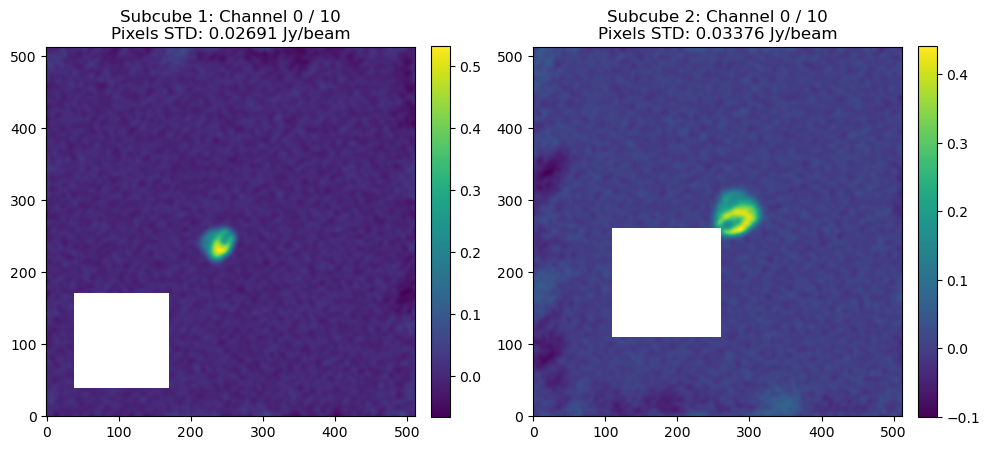

In [38]:
print(f"Data cube shape: {data_cube.data.shape}")
print(f"Resampled data shape: {data.shape}")

subcube1 = data.copy()[:10, :, :]
subcube2 = data.copy()[-10:, :, :]

ax, bx = 40, 170  # x-slice
ay, by = 40, 170  # y-slice

subcube1[:, ax:bx, ay:by] = np.nan

ax, bx = 110, 260  # x-slice
ay, by = 110, 260  # y-slice

subcube2[:, ax:bx, ay:by] = np.nan

merged_subcube = np.concatenate((subcube1, subcube2), axis=0)
print("merged_subcube shape:", merged_subcube.shape)  # (20, 282, 282)

noise_pixels = merged_subcube[~np.isnan(merged_subcube)]
noise_sigma = np.std(noise_pixels) # RMS
print(f"Noise sigma (std): {noise_sigma:.3f}")

fig, axes = plt.subplots(ncols=2, figsize=(10, 5))

# Plot first channel of subcube1
im1 = axes[0].imshow(subcube1[0], origin='lower', cmap='viridis')
axes[0].set_title(f"Subcube 1: Channel 0 / 10\nPixels STD: {np.nanstd(subcube1[0]):.5f} Jy/beam")
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Plot first channel of subcube2
im2 = axes[1].imshow(subcube2[0], origin='lower', cmap='viridis')
axes[1].set_title(f"Subcube 2: Channel 0 / 10\nPixels STD: {np.nanstd(subcube2[0]):.5f} Jy/beam")
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [39]:
beam = data_cube.beams_per_pix * sensor.beam(
    data_cube.dpix, data_cube.bmaj, data_cube.bmin, data_cube.bpa
)

# Shift frequencies so that center is ~nu0
freqs += nu0 - freqs.mean()

projection_pinhole = sensor.PinholeProjection(
    name='HD163296',
    x_sky=x_sky,
    y_sky=y_sky,
    distance=122.0,
    nray=100,
    incl=47.5,
    phi=0.0,
    posang=312.0,
    z_width=2 * z_max,
    freqs=freqs
)

fov_rad = fov_as * arcsec
fov = 2 * projection_pinhole.distance * pc * np.tan(fov_rad / 2.0)
pixel_area_pinhole = (fov / npix) ** 2

ray_coords_pinhole, obs_dir_pinhole = sensor.pinhole_disk_projection(
    projection_pinhole.x_sky,
    projection_pinhole.y_sky,
    projection_pinhole.distance,
    projection_pinhole.nray,
    projection_pinhole.incl,
    projection_pinhole.phi,
    projection_pinhole.posang,
    projection_pinhole.z_width
)

In [40]:
################################################################################
# 8) Render the cubes via the new functional approach
################################################################################
images = render_cube_pinhole(
    ray_coords_pinhole,
    pixel_area_pinhole,
    disk_params,
    nd_co,
    temperature,
    -velocity_az,  # note sign convention
    bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)

computing pinhole spectral cube for a total of 100 frequencies


2025-02-03 19:01:57.795828: W external/xla/xla/service/hlo_rematerialization.cc:3005] Can't reduce memory use below 15.07GiB (16184589895 bytes) by rematerialization; only reduced to 29.98GiB (32189186000 bytes), down from 31.05GiB (33342619656 bytes) originally
2025-02-03 19:02:08.482828: W external/xla/xla/tsl/framework/bfc_allocator.cc:497] Allocator (GPU_0_bfc) ran out of memory trying to allocate 30.47GiB (rounded to 32713474560)requested by op 
2025-02-03 19:02:08.483204: W external/xla/xla/tsl/framework/bfc_allocator.cc:508] ************************************************************____****________________________________
2025-02-03 19:02:08.483254: W external/xla/xla/tsl/framework/bfc_allocator.cc:497] Allocator (GPU_1_bfc) ran out of memory trying to allocate 30.47GiB (rounded to 32713474560)requested by op 
E0203 19:02:08.483263  987952 pjrt_stream_executor_client.cc:3084] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 32713474320 

XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 32713474320 bytes.: while running replica 0 and partition 0 of a replicated computation (other replicas may have failed as well).

In [15]:
###############################################################################
# 9) Convolve images with the beam
################################################################################

images_blurred = sensor.fftconvolve_vmap(images, beam)

noise = np.random.normal(0, noise_sigma * np.max(images), images.shape)
images_noisy = images + noise
images_noisy_blurred = sensor.fftconvolve_vmap(images_noisy, beam)

In [16]:
bmaj_std_pix = data_cube.bmaj / data_cube.dpix / 2.355
bmin_std_pix = data_cube.bmin / data_cube.dpix / 2.355
bmaj_std_pix, bmin_std_pix

(np.float64(4.56522463651526), np.float64(4.100352036007074))

In [17]:
images_blurred.shape

(30, 282, 282)

In [18]:
beam.shape

(37, 37)

## Compute pixels correlation based on given beam

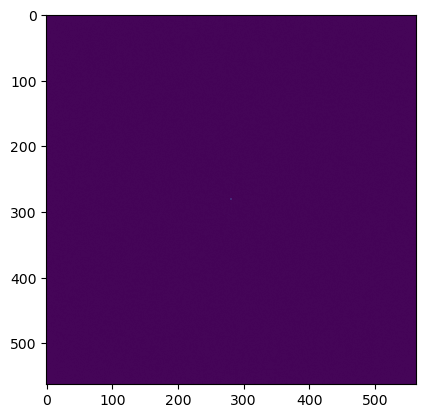

In [15]:
from scipy.signal import correlate2d, fftconvolve

nx = 282
noise_image = np.random.normal(loc=0.0, scale=1.0, size=(nx, nx))
convolved_image = fftconvolve(noise_image, beam, mode='same')

plt.imshow(correlate2d(noise_image, noise_image, mode='full', boundary='fill'))

In [ ]:
plt.imshow(correlate2d(convolved_image, convolved_image, mode='full', boundary='fill'))

In [ ]:
stride = 2
plt.imshow(correlate2d(convolved_image[::stride, ::stride], convolved_image[::stride, ::stride], mode='full', boundary='fill'))

In [ ]:
stride = 5
plt.imshow(correlate2d(convolved_image[::stride, ::stride], convolved_image[::stride, ::stride], mode='full', boundary='fill'))

In [19]:
nx, ny = 282, 282
image = noise_image
row_correlations = []
for row in range(nx):
    row_vals = image[row, :] 
    # correlation between row_vals and row_vals shifted by 1 pixel
    # e.g. corr between row_vals[:-1] and row_vals[1:]
    corr = np.corrcoef(row_vals[:-1], row_vals[1:])[0,1]
    row_correlations.append(corr)

mean_horizontal_corr = np.mean(row_correlations)
print("Mean horizontal correlation:", mean_horizontal_corr)

# Similarly for vertical correlation
col_correlations = []
for col in range(ny):
    col_vals = image[:, col]
    corr = np.corrcoef(col_vals[:-1], col_vals[1:])[0,1]
    col_correlations.append(corr)

mean_vertical_corr = np.mean(col_correlations)
print("Mean vertical correlation:", mean_vertical_corr)

Mean horizontal correlation: -0.0024148660087216847
Mean vertical correlation: -0.0034830879809404475


In [20]:
image = convolved_image
row_correlations = []
for row in range(nx):
    row_vals = image[row, :] 
    # correlation between row_vals and row_vals shifted by 1 pixel
    # e.g. corr between row_vals[:-1] and row_vals[1:]
    corr = np.corrcoef(row_vals[:-1], row_vals[1:])[0,1]
    row_correlations.append(corr)

mean_horizontal_corr = np.mean(row_correlations)
print("Mean horizontal correlation:", mean_horizontal_corr)

# Similarly for vertical correlation
col_correlations = []
for col in range(ny):
    col_vals = image[:, col]
    corr = np.corrcoef(col_vals[:-1], col_vals[1:])[0,1]
    col_correlations.append(corr)

mean_vertical_corr = np.mean(col_correlations)
print("Mean vertical correlation:", mean_vertical_corr)

Mean horizontal correlation: 0.9871637549587556
Mean vertical correlation: 0.9838370599254063


In [21]:
stride = 2
image = convolved_image[::stride,::stride]
row_correlations = []
for row in range(nx//stride):
    row_vals = image[row, :] 
    # correlation between row_vals and row_vals shifted by 1 pixel
    # e.g. corr between row_vals[:-1] and row_vals[1:]
    corr = np.corrcoef(row_vals[:-1], row_vals[1:])[0,1]
    row_correlations.append(corr)

mean_horizontal_corr = np.mean(row_correlations)
print(f"Mean horizontal correlation of stride {stride}:", mean_horizontal_corr)

# Similarly for vertical correlation
col_correlations = []
for col in range(ny//stride):
    col_vals = image[:, col]
    corr = np.corrcoef(col_vals[:-1], col_vals[1:])[0,1]
    col_correlations.append(corr)

mean_vertical_corr = np.mean(col_correlations)
print(f"Mean vertical correlation of stride {stride}:", mean_vertical_corr)

Mean horizontal correlation of stride 2: 0.9495158667580433
Mean vertical correlation of stride 2: 0.9367784458886845


In [22]:
stride = 5
image = convolved_image[::stride,::stride]
row_correlations = []
for row in range(nx//stride):
    row_vals = image[row, :] 
    # correlation between row_vals and row_vals shifted by 1 pixel
    # e.g. corr between row_vals[:-1] and row_vals[1:]
    corr = np.corrcoef(row_vals[:-1], row_vals[1:])[0,1]
    row_correlations.append(corr)

mean_horizontal_corr = np.mean(row_correlations)
print(f"Mean horizontal correlation of stride {stride}:", mean_horizontal_corr)

# Similarly for vertical correlation
col_correlations = []
for col in range(ny//stride):
    col_vals = image[:, col]
    corr = np.corrcoef(col_vals[:-1], col_vals[1:])[0,1]
    col_correlations.append(corr)

mean_vertical_corr = np.mean(col_correlations)
print(f"Mean vertical correlation of stride {stride}:", mean_vertical_corr)

Mean horizontal correlation of stride 5: 0.7204660393978809
Mean vertical correlation of stride 5: 0.6608118981928867


In [23]:
stride = 8
image = convolved_image[::stride,::stride]
row_correlations = []
for row in range(nx//stride):
    row_vals = image[row, :] 
    # correlation between row_vals and row_vals shifted by 1 pixel
    # e.g. corr between row_vals[:-1] and row_vals[1:]
    corr = np.corrcoef(row_vals[:-1], row_vals[1:])[0,1]
    row_correlations.append(corr)

mean_horizontal_corr = np.mean(row_correlations)
print(f"Mean horizontal correlation of stride {stride}:", mean_horizontal_corr)

# Similarly for vertical correlation
col_correlations = []
for col in range(ny//stride):
    col_vals = image[:, col]
    corr = np.corrcoef(col_vals[:-1], col_vals[1:])[0,1]
    col_correlations.append(corr)

mean_vertical_corr = np.mean(col_correlations)
print(f"Mean vertical correlation of stride {stride}:", mean_vertical_corr)

Mean horizontal correlation of stride 8: 0.4296650788961319
Mean vertical correlation of stride 8: 0.32629656936901796


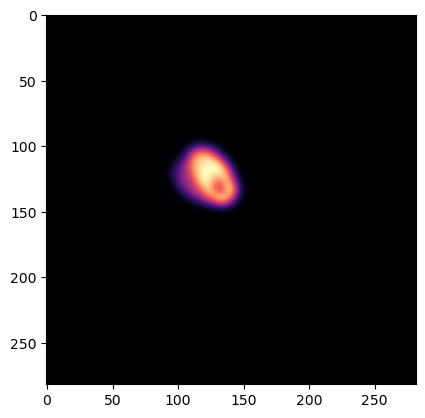

In [24]:
# Plotting Comparison
%matplotlib inline
image_index = 0
# Pinhole Projection Image
plt.imshow(images_blurred[image_index, :, :], cmap="magma")
# plt.savefig(f"projection_compare_{image_index}.png")
plt.show()

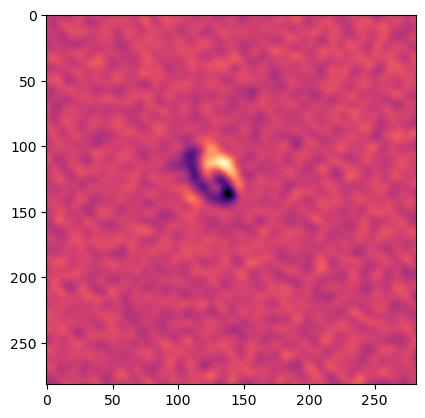

In [25]:
plt.imshow(data[image_index,:,:] - images_blurred[image_index, :, :], cmap="magma")

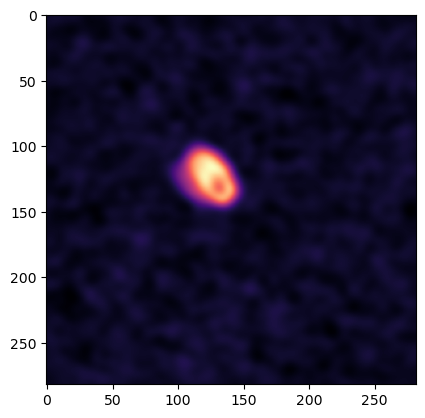

In [26]:
# Plotting Comparison
%matplotlib inline

image_index = 0

# Pinhole Projection Image
plt.imshow(images_noisy_blurred[image_index, :, :], cmap="magma")
# plt.savefig(f"projection_compare_{image_index}.png")
plt.show()

# Demo MCMC on synthetic observation

In [15]:
import inference 

param_index_dict = inference.DISK_PARAM_INDEX
################################################################################
# 1) Set up the single-parameter prior for v_turb
################################################################################
posterior_params = {
    param_index_dict['q']: {
        'bounds': [-0.5, 0.0],
        'p0_range': [-0.3, -0.1],
    },
    param_index_dict['log_r_c']: {
        'bounds': [1.75, 2.50],
        'p0_range': [2.00, 2.30],
    },
    param_index_dict['v_turb']: {
        'bounds': [0.0, 1.0],
        'p0_range': [0.05, 0.15],
    },
    param_index_dict['T_atm1']: {
        'bounds': [40.0, 150.0],
        'p0_range': [60.0, 110.0],
    },
    param_index_dict['T_mid1']: {
        'bounds': [5.0, 40.0],
        'p0_range': [10.0, 30.0],
    },
    param_index_dict['r_in']: {
        'bounds': [1.0, 20.0],
        'p0_range': [5.0, 15.0],
    },
    param_index_dict['r_break']: {
        'bounds': [15.0, 115.0],
        'p0_range': [50.0, 80.0],
    },
    param_index_dict['q_in']: {
        'bounds': [-1.0, 0.0],
        'p0_range': [-0.7, -0.3],
    }
}

# Our disk_params dictionary (already created), e.g.:
disk_params_mcmc = parametric_disk.create_disk_params(
    T_mid1=20.0,
    T_atm1=80.0,
    q=-0.15,
    q_in=-0.5,
    r_break=60,
    M_star=2.3 * M_sun,
    gamma=1.0,
    r_in=11.0,
    log_r_c=2,
    M_gas=0.09 * M_sun,
    v_turb=1.0,
    co_abundance=1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h
)

ray_coords_sph = grid.cartesian_to_spherical(ray_coords_pinhole)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
energy_levels, radiative_transitions = line_rte.load_molecular_tables(
    path="/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"
)

In [16]:
################################################################################
# 2) Create the sampler_dict for the new functional inference
################################################################################
sampler_dict = inference.create_sampler(
    z_disk=z_disk,
    r_disk=r_disk,
    bbox=bbox_disk,
    pixel_area=pixel_area_pinhole,
    ray_coords=ray_coords_pinhole,
    ray_coords_polar=grid.spherical_to_zr(grid.cartesian_to_spherical(ray_coords_pinhole)),
    obs_dir=obs_dir_pinhole,
    beam=beam,
    energy_levels=energy_levels,
    radiative_transitions=radiative_transitions,
    sigma=0.05,
    disk_params=disk_params_mcmc,
    posterior_params=posterior_params,
    stride=5
)

In [17]:
################################################################################
# 3) Initialize the walkers
################################################################################
ndim = len(list(posterior_params.keys()))    
nwalkers = 48
nsteps = 1000 # Example number of MCMC steps
num_iter_restart = 150
restart_cluster_size = 1e-2

# Sample initial positions p0 from the param_bounds
p0 = inference.sample_p0(nwalkers, posterior_params, seed=1337)

In [ ]:
################################################################################
# 4) Set up and run the emcee MCMC
################################################################################
backend = emcee.backends.HDFBackend("mcmc_sampler.h5")
backend.reset(nwalkers, ndim)

def logprob_wrapper(params):
    """
    A small wrapper that calls the functional logprob with the 
    arguments we need: the data (images_ground_truth_blurred) 
    and frequencies, plus the sampler_dict.
    """
    return inference.logprob(params, images_noisy_blurred, freqs, sampler_dict, sampler_dict['stride'])

sampler = emcee.EnsembleSampler(
    nwalkers=nwalkers,
    ndim=ndim,
    log_prob_fn=logprob_wrapper,
    backend=backend
)

print("Running MCMC...")
warmup_sampler = sampler.run_mcmc(p0, 100, progress=True)
flat_samples = sampler.get_chain(flat=True)
warmup_medians = np.median(flat_samples, axis=0)
p1 = np.random.normal(warmup_medians,  restart_cluster_size * np.abs(warmup_medians), size=(nwalkers, ndim))

start_time_mcmc = time.time()
sampler.run_mcmc(p1, nsteps, progress=True)
end_time_mcmc = time.time()
mcmc_time = end_time_mcmc - start_time_mcmc
print(f"MCMC completed in {mcmc_time:.2f} seconds.")

Running MCMC...


 89%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                | 89/100 [33:06<04:05, 22.35s/it]

In [152]:
################################################################################
# 6) Update the disk_params with the MCMC result and re-render
################################################################################
# 1) Flatten chain
flat_samples = sampler.get_chain(discard=500, flat=True)

# 2) Sort param indices to match the sampling order
sorted_indices = sorted(posterior_params.keys())

# 3) Loop over parameters and update disk_params_mcmc with medians
for col, param_index in enumerate(sorted_indices):
    name = inference.REV_DISK_PARAM_INDEX[param_index]
    median_val = np.median(flat_samples[:, col])
    disk_params_mcmc[name] = median_val


# Recompute temperature and densities with updated v_turb
temperature_mcmc = parametric_disk.temperature_profile(z_disk, r_disk, disk_params_mcmc)
nd_h2_mcmc = parametric_disk.number_density_profile(
    z_disk,
    r_disk,
    temperature_mcmc,
    disk_params_mcmc["gamma"],
    disk_params_mcmc["r_in"],
    10 ** disk_params_mcmc["log_r_c"],
    disk_params_mcmc["M_gas"],
    disk_params_mcmc["M_star"],
    disk_params_mcmc["m_mol"]
)

velocity_az_mcmc = -parametric_disk.velocity_profile(
    z_disk, r_disk, nd_h2_mcmc, temperature_mcmc, disk_params_mcmc
)

N_h2_mcmc = parametric_disk.surface_density(z_disk, nd_h2_mcmc)
abundance_co_mcmc = parametric_disk.co_abundance_profile(N_h2_mcmc, temperature_mcmc, disk_params_mcmc)
nd_co_mcmc = abundance_co_mcmc * nd_h2_mcmc

# Render new cube with the updated v_turb
images_mcmc = render_cube_pinhole(
    ray_coords=ray_coords_pinhole,
    pixel_area=pixel_area_pinhole,
    disk_params=disk_params_mcmc,       # pass the dictionary instead of a disk object
    nd_co=nd_co_mcmc,
    temperature=temperature_mcmc,
    velocity_az=velocity_az_mcmc,
    bbox=bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)

images_mcmc_blurred = sensor.fftconvolve_vmap(images_mcmc, beam)

residual_mcmc = images_noisy_blurred - images_mcmc_blurred
chi2_mcmc = np.sum(((images_noisy_blurred - images_mcmc_blurred) / 0.05)**2)
residual_sum_mcmc = np.sum(np.abs(residual_mcmc))
residual_mean_mcmc = np.mean(np.abs(residual_mcmc))

n_data = np.prod(data.shape)
chi_squared_over_n_data = chi2_mcmc / n_data

print(f"MCMC Chi-squared: {chi2_mcmc:.2f}, Chi-squared/N_data = {chi_squared_over_n_data}")
print(f"MCMC Residual Sum: {residual_sum_mcmc:.2f}")
print(f"MCMC Residual Mean: {residual_mean_mcmc:.2f}")

computing pinhole spectral cube for a total of 60 frequencies


NameError: name 'images_noisy_blurred' is not defined

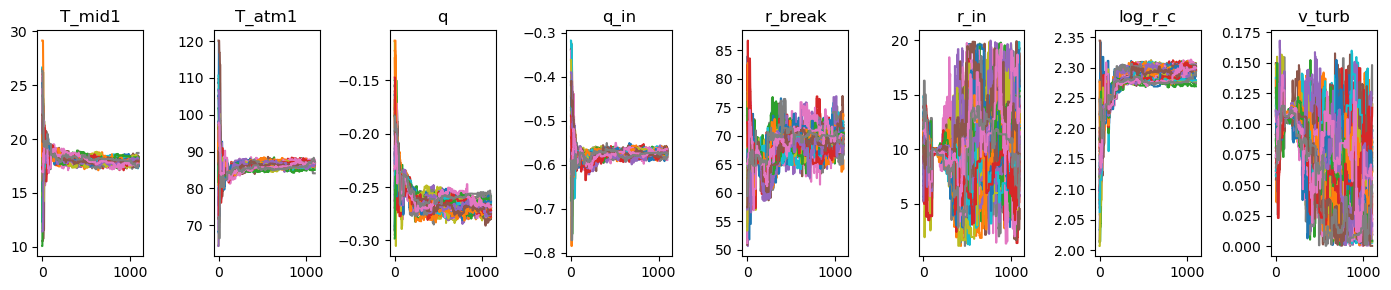

In [20]:
chain = sampler.get_chain()

ndim = chain.shape[-1]
param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

%matplotlib inline
fig, axes = plt.subplots(1, ndim, figsize=(14,3))
for i in range(ndim):
    axes[i].plot(chain[...,i])
    axes[i].set_title(param_labels[i])

plt.tight_layout()

Flat samples shape: (28800, 8)


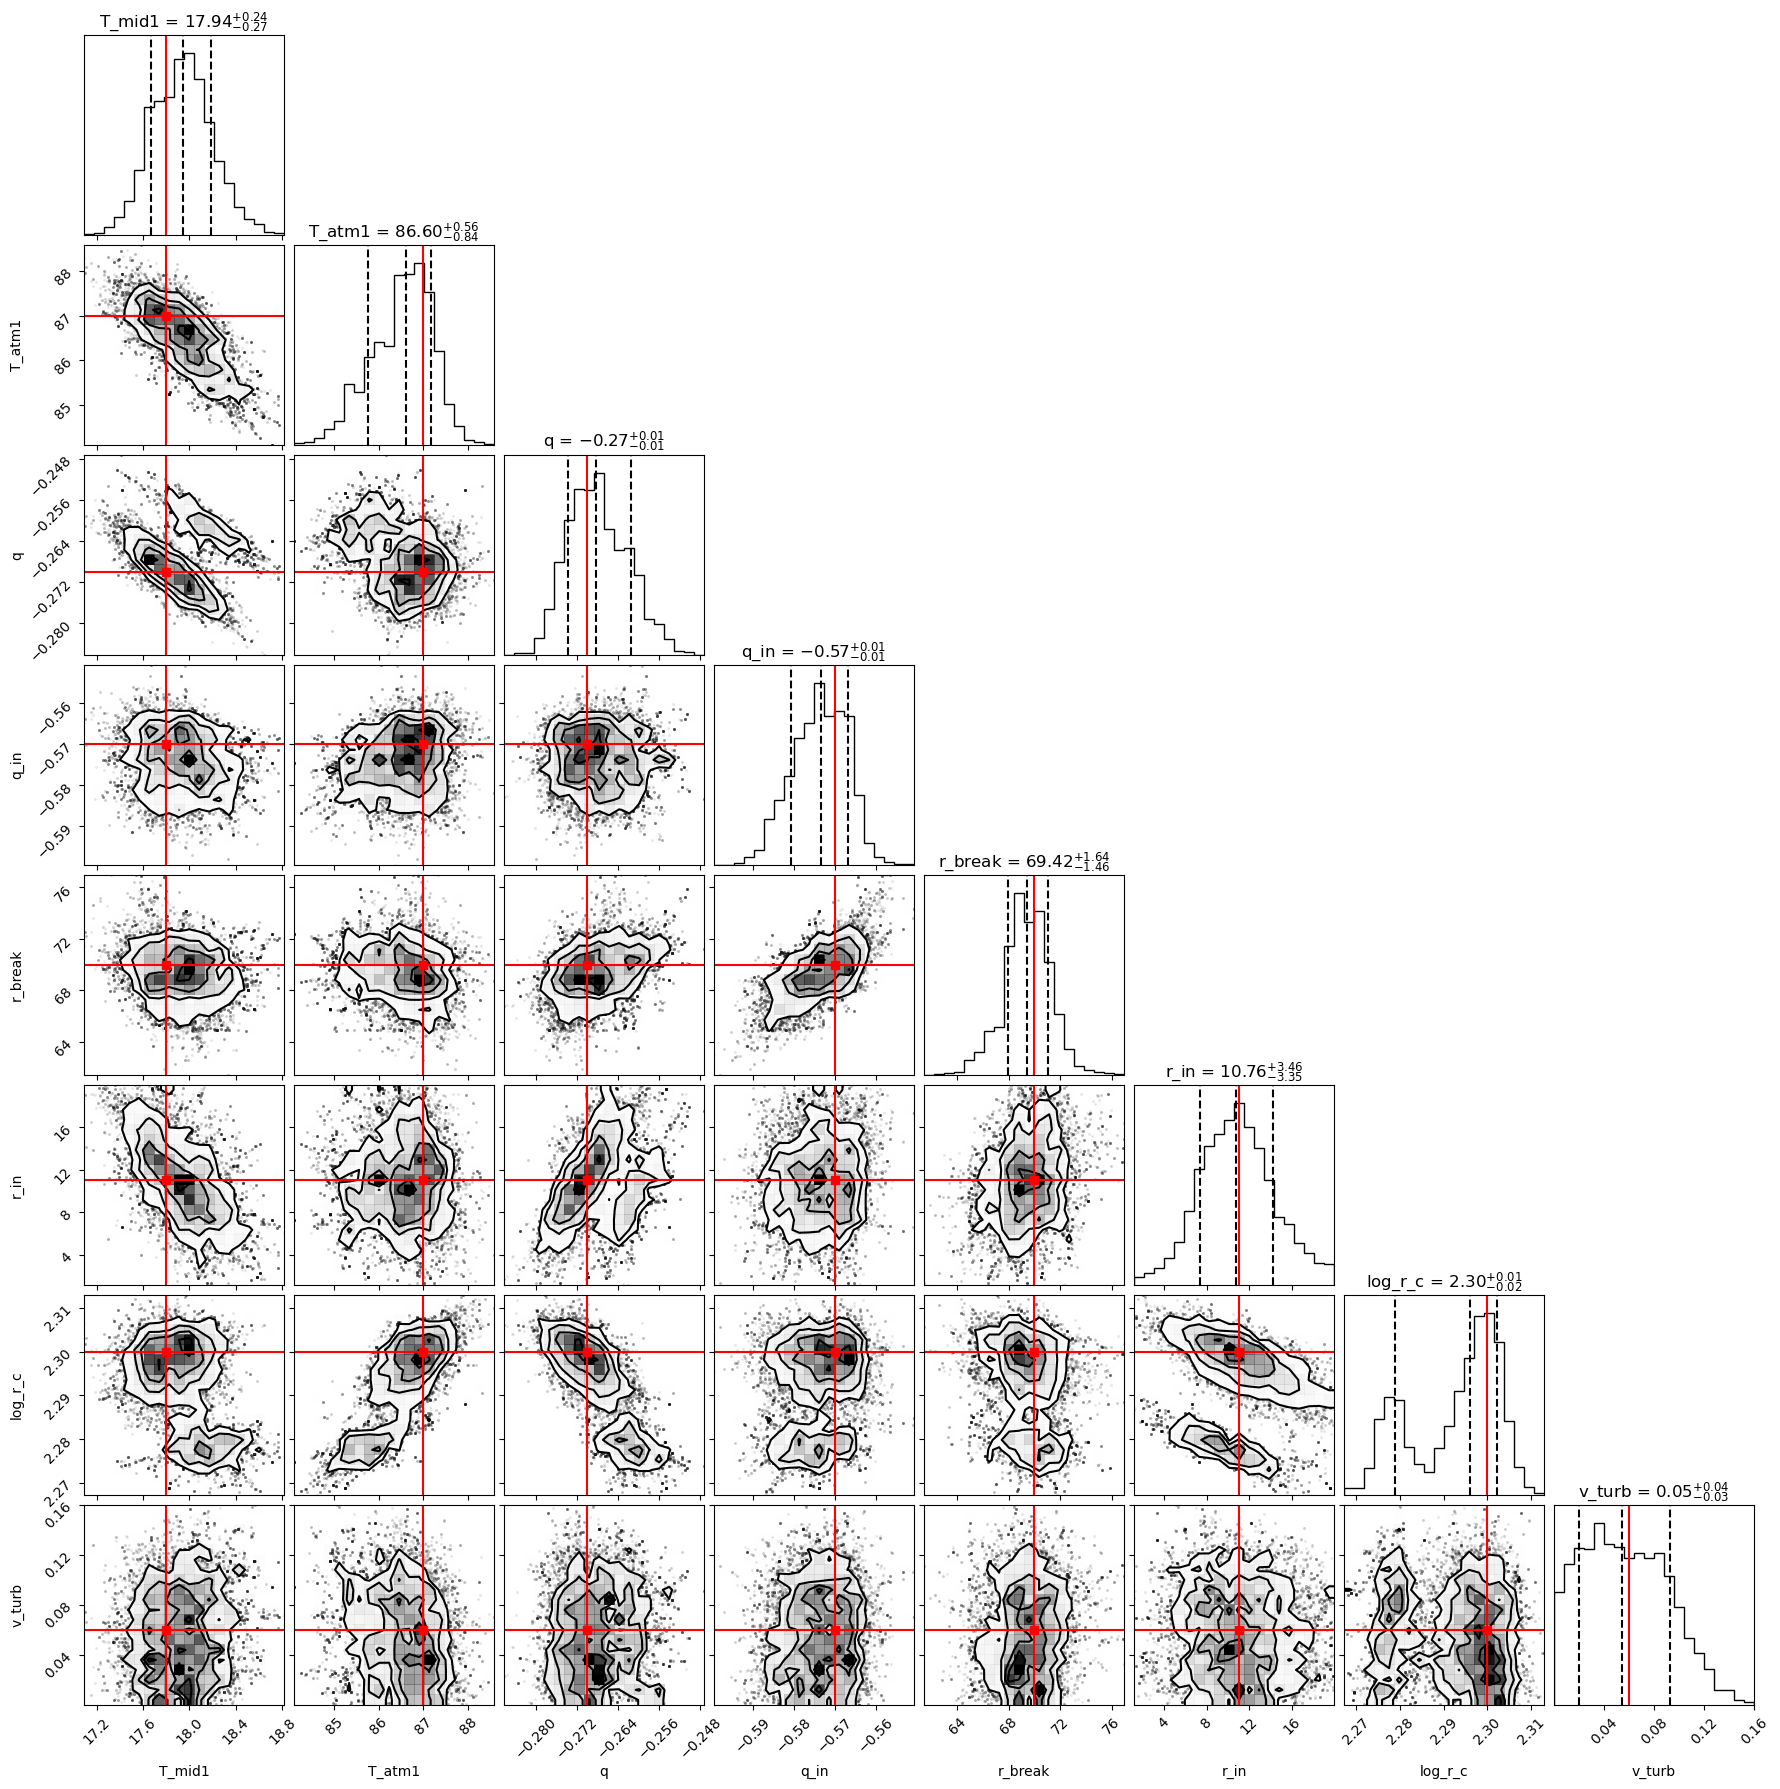

In [23]:
%matplotlib inline
import corner

# Discard first 100 steps, flatten the rest
flat_samples = sampler.get_chain(discard=500, thin=1, flat=True)
print("Flat samples shape:", flat_samples.shape)  # should be ((nsteps-100)*nwalkers, ndim)

param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

truth_values = [ground_truth[label] for label in param_labels]

# corner plot
fig = corner.corner(
    flat_samples,
    labels=param_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    truths=truth_values,        # <--- overlay true values
    truth_color="red",          # optional color
    title_kwargs={"fontsize": 12}
)

In [22]:
burnin = 500  # example number of steps to discard
flat_samples = sampler.get_chain(discard=burnin, flat=True)
# shape is ((nsteps-burnin)*nwalkers, ndim)

print("flat_samples shape:", flat_samples.shape)

ground_truth = {
    "q": -0.27,
    "log_r_c": 2.3,
    "v_turb": 0.06,
    "T_atm1": 87.0,
    "T_mid1": 17.8,
    "r_in": 11.0,
    "r_break": 70.0,
    "q_in": -0.57
}

# for i, label in enumerate(param_labels):
#     p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
#     median_val = p50
#     minus_err = p50 - p16
#     plus_err  = p84 - p50
#     print(f"{label:8s}: {median_val:.3f} +{plus_err:.3f} -{minus_err:.3f}")
    
for i, label in enumerate(param_labels):
    gt_val = ground_truth[label]  # ground truth
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    print(f"{label:8s} | True: {gt_val:.3f} "
          f"| MCMC: {p50:.3f} (+{p84 - p50:.3f} / -{p50 - p16:.3f})")

flat_samples shape: (28800, 8)
T_mid1   | True: 17.800 | MCMC: 17.942 (+0.242 / -0.271)
T_atm1   | True: 87.000 | MCMC: 86.600 (+0.563 / -0.836)
q        | True: -0.270 | MCMC: -0.268 (+0.007 / -0.005)
q_in     | True: -0.570 | MCMC: -0.573 (+0.007 / -0.007)
r_break  | True: 70.000 | MCMC: 69.422 (+1.643 / -1.457)
r_in     | True: 11.000 | MCMC: 10.761 (+3.459 / -3.350)
log_r_c  | True: 2.300 | MCMC: 2.296 (+0.006 / -0.017)
v_turb   | True: 0.060 | MCMC: 0.055 (+0.038 / -0.035)


In [ ]:
disk_params_mcmc

## MCMC on Flaherty observation

In [ ]:
import inference 

param_index_dict = inference.DISK_PARAM_INDEX

################################################################################
# 1) Set up the single-parameter prior for v_turb
################################################################################
posterior_params = {
    param_index_dict['q']: {
        'bounds': [-0.5, 0.0],
        'p0_range': [-0.5, 0.0],
    },
    param_index_dict['log_r_c']: {
        'bounds': [1.75, 2.50],
        'p0_range': [1.75, 2.50],
    },
    param_index_dict['v_turb']: {
        'bounds': [0.0, 1.0],
        'p0_range': [0.0, 1.0],
    },
    param_index_dict['T_atm1']: {
        'bounds': [40.0, 150.0],
        'p0_range': [40.0, 150.0],
    },
    param_index_dict['T_mid1']: {
        'bounds': [5.0, 40.0],
        'p0_range': [5.0, 40.0],
    },
    param_index_dict['r_in']: {
        'bounds': [1.0, 20.0],
        'p0_range': [1.0, 20.0],
    },
    param_index_dict['r_break']: {
        'bounds': [15.0, 115.0],
        'p0_range': [15.0, 115.0],
    },
    param_index_dict['q_in']: {
        'bounds': [-1.0, 0.0],
        'p0_range': [-1.0, 0.0],
    }
}

# Our disk_params dictionary (already created), e.g.:
disk_params_mcmc = parametric_disk.create_disk_params(
    T_mid1=20.0,
    T_atm1=80.0,
    q=-0.15,
    q_in=-0.5,
    r_break=60,
    M_star=2.3 * M_sun,
    gamma=1.0,
    r_in=11.0,
    log_r_c=2,
    M_gas=0.09 * M_sun,
    v_turb=0.1,
    co_abundance=1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h
)

ray_coords_sph = grid.cartesian_to_spherical(ray_coords_pinhole)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
energy_levels, radiative_transitions = line_rte.load_molecular_tables(
    path="/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"
)

################################################################################
# 2) Create the sampler_dict for the new functional inference
################################################################################
sampler_dict = inference.create_sampler(
    z_disk=z_disk,
    r_disk=r_disk,
    bbox=bbox_disk,
    pixel_area=pixel_area_pinhole,
    ray_coords=ray_coords_pinhole,
    ray_coords_polar=grid.spherical_to_zr(grid.cartesian_to_spherical(ray_coords_pinhole)),
    obs_dir=obs_dir_pinhole,
    beam=beam,
    energy_levels=energy_levels,
    radiative_transitions=radiative_transitions,
    sigma=noise_sigma,
    disk_params=disk_params_mcmc,
    posterior_params=posterior_params,
    stride=5
)

print('Using sigma =', sampler_dict['sigma'])

################################################################################
# 3) Initialize the walkers
################################################################################
ndim = len(list(posterior_params.keys()))    
nwalkers = 80
nsteps = 1500 # Example number of MCMC steps
num_iter_restart = 150
restart_cluster_size = 1e-2

# Sample initial positions p0 from the param_bounds
p0 = inference.sample_p0(nwalkers, posterior_params, seed=1337)

################################################################################
# 4) Set up and run the emcee MCMC
################################################################################
backend = emcee.backends.HDFBackend("new_sigma_sampler_30freqs.h5")
backend.reset(nwalkers, ndim)

def logprob_wrapper(params):
    """
    A small wrapper that calls the functional logprob with the 
    arguments we need: the data (images_ground_truth_blurred) 
    and frequencies, plus the sampler_dict.
    """
    return inference.logprob(params, data, freqs, sampler_dict, sampler_dict['stride'])

sampler = emcee.EnsembleSampler(
    nwalkers=nwalkers,
    ndim=ndim,
    log_prob_fn=logprob_wrapper,
    backend=backend
)

print("Running MCMC...")
warmup_sampler = sampler.run_mcmc(p0, 100, progress=True)
flat_samples = sampler.get_chain(flat=True)
warmup_medians = np.median(flat_samples, axis=0)
p1 = np.random.normal(warmup_medians,  restart_cluster_size * np.abs(warmup_medians), size=(nwalkers, ndim))

start_time_mcmc = time.time()
sampler.run_mcmc(p1, nsteps, progress=True)
end_time_mcmc = time.time()
mcmc_time = end_time_mcmc - start_time_mcmc
print(f"MCMC completed in {mcmc_time:.2f} seconds.")

ground_truth = {
    "q": -0.27,
    "log_r_c": 2.3,
    "v_turb": 0.06,
    "T_atm1": 87.0,
    "T_mid1": 17.8,
    "r_in": 11.0,
    "r_break": 70.0,
    "q_in": -0.57
}

chain = sampler.get_chain()

ndim = chain.shape[-1]
param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

%matplotlib inline
fig, axes = plt.subplots(1, ndim, figsize=(14,3))
for i in range(ndim):
    axes[i].plot(chain[...,i])
    axes[i].set_title(param_labels[i])

plt.tight_layout()

%matplotlib inline
import corner

flat_samples = sampler.get_chain(discard=500, thin=1, flat=True)
print("Flat samples shape:", flat_samples.shape)  # should be ((nsteps-100)*nwalkers, ndim)

param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

truth_values = [ground_truth[label] for label in param_labels]

# corner plot
fig = corner.corner(
    flat_samples,
    labels=param_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    truths=truth_values,        # <--- overlay true values
    truth_color="red",          # optional color
    title_kwargs={"fontsize": 12}
)

Using sigma = 0.0069853244
Running MCMC...


 51%|████████████████████████████████████████████████████████████████████████████▌                                                                         | 51/100 [15:41<15:09, 18.56s/it]

Flat samples shape: (88000, 8)


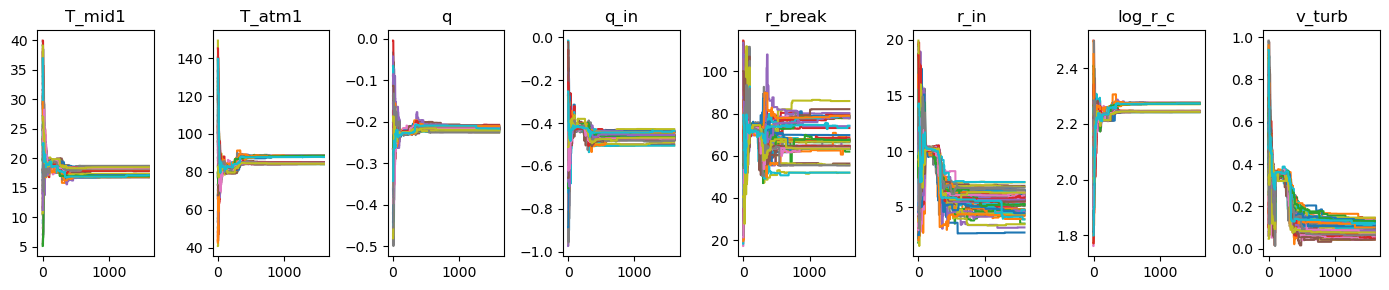

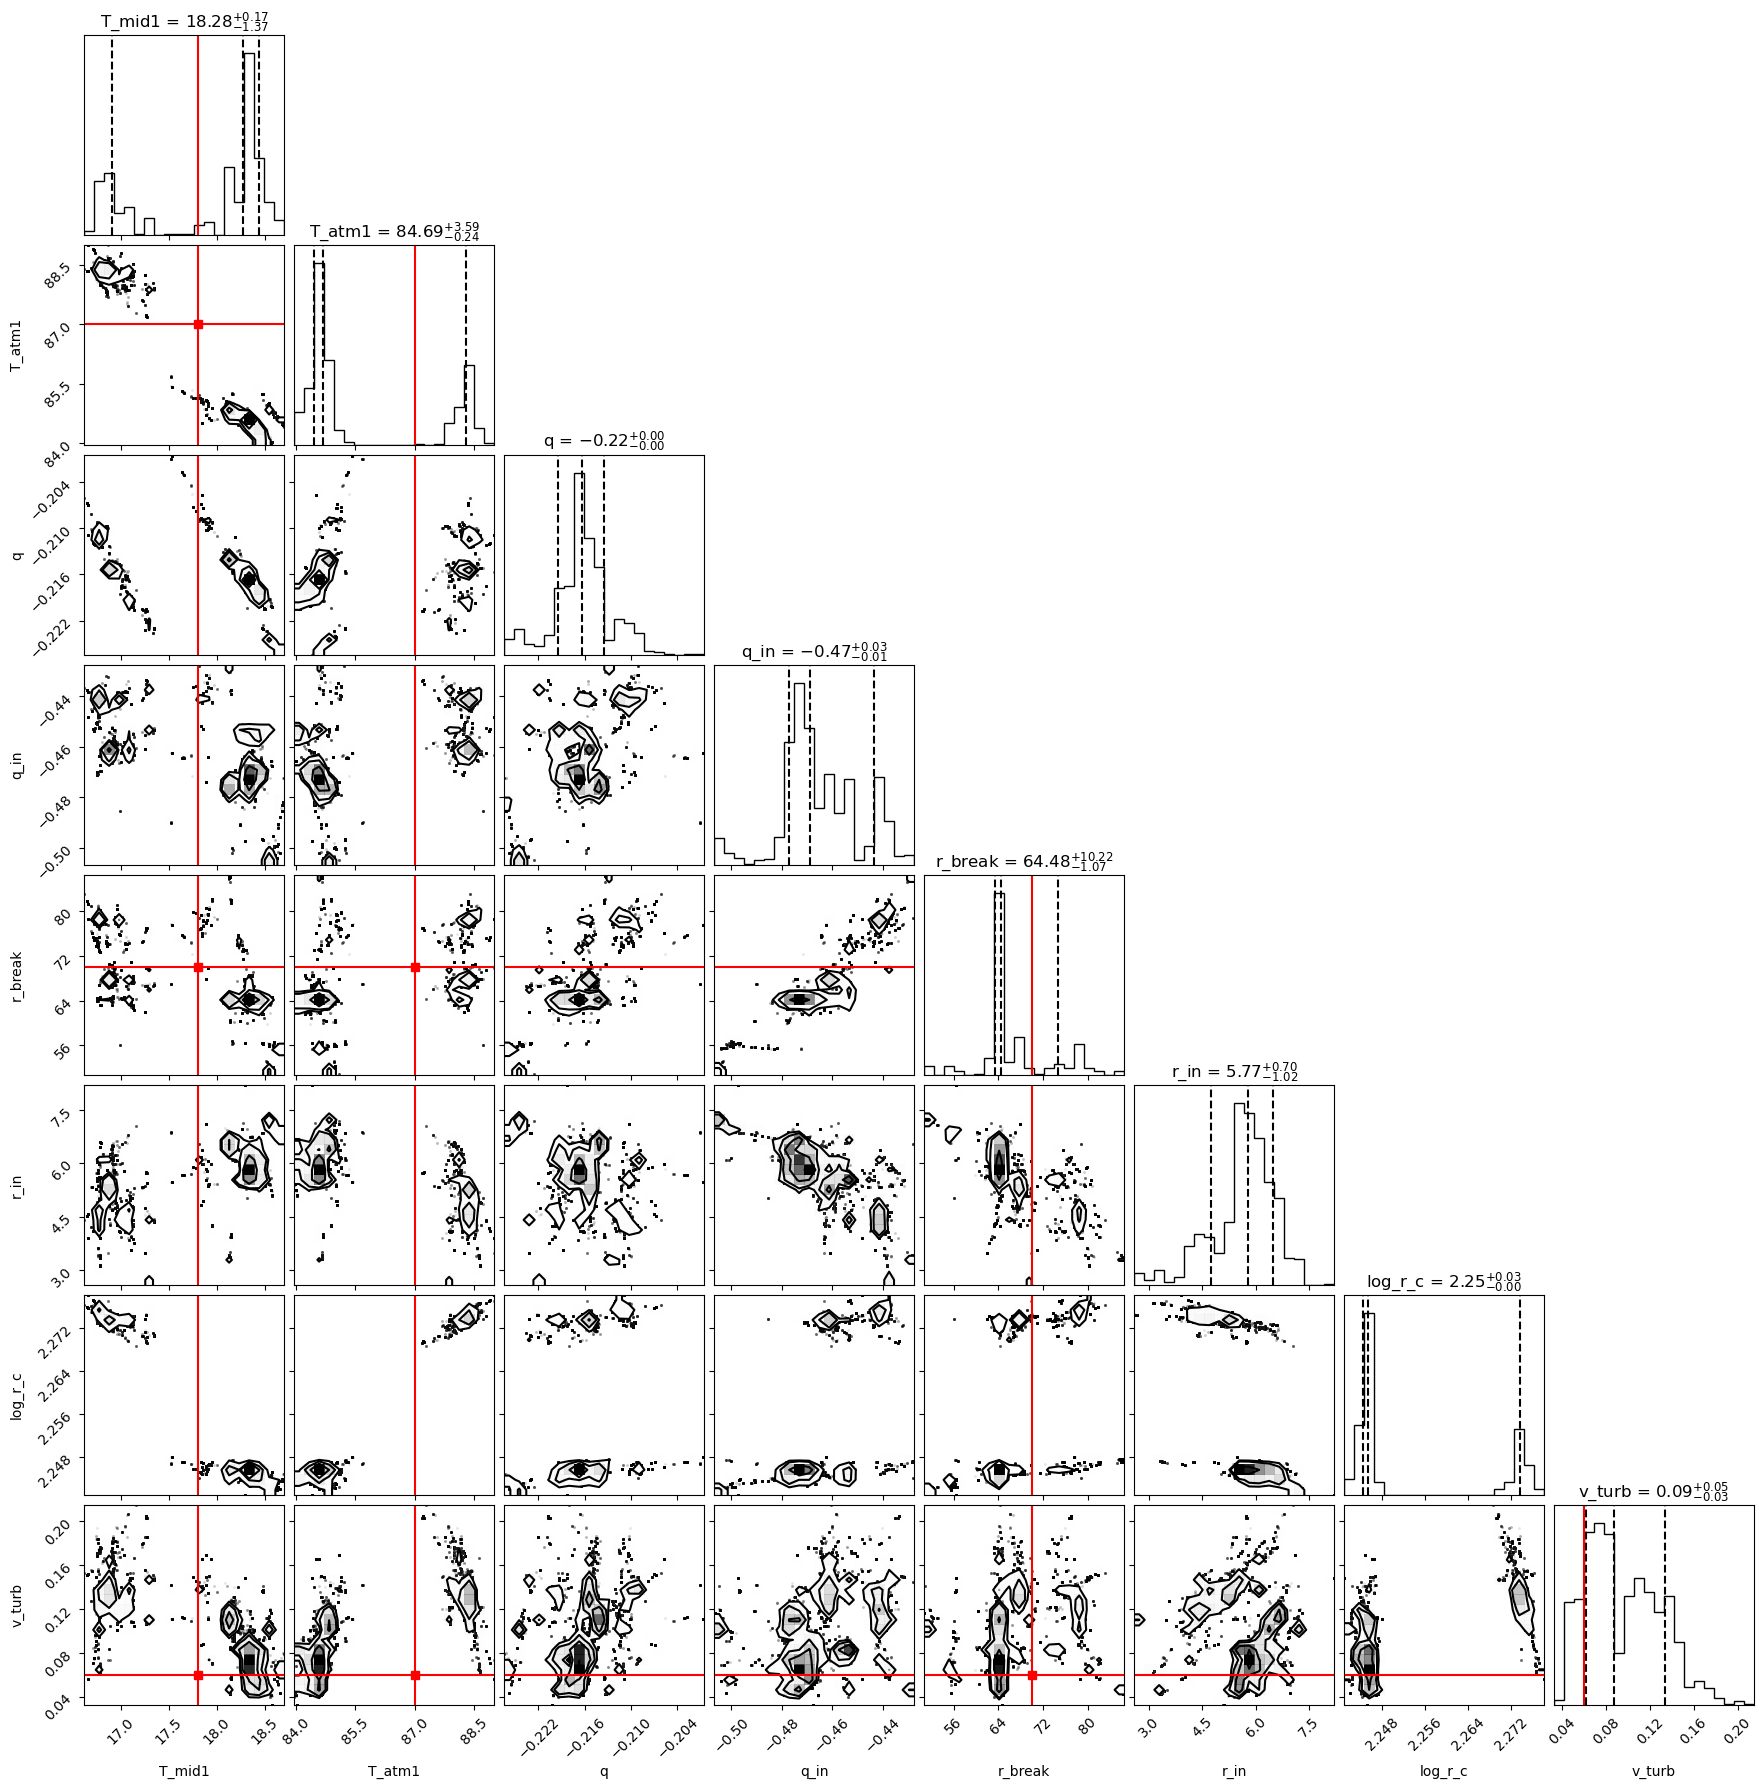

In [25]:
sampler = emcee.backends.HDFBackend("new_sigma_sampler_30freqs.h5")

ground_truth = {
    "q": -0.27,
    "log_r_c": 2.3,
    "v_turb": 0.06,
    "T_atm1": 87.0,
    "T_mid1": 17.8,
    "r_in": 11.0,
    "r_break": 70.0,
    "q_in": -0.57
}

chain = sampler.get_chain()

ndim = chain.shape[-1]
param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

%matplotlib inline
fig, axes = plt.subplots(1, ndim, figsize=(14,3))
for i in range(ndim):
    axes[i].plot(chain[...,i])
    axes[i].set_title(param_labels[i])

plt.tight_layout()

%matplotlib inline
import corner

flat_samples = sampler.get_chain(discard=500, thin=1, flat=True)
print("Flat samples shape:", flat_samples.shape)  # should be ((nsteps-100)*nwalkers, ndim)

param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

truth_values = [ground_truth[label] for label in param_labels]

# corner plot
fig = corner.corner(
    flat_samples,
    labels=param_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    truths=truth_values,        # <--- overlay true values
    truth_color="red",          # optional color
    title_kwargs={"fontsize": 12}
)

In [26]:
ground_truth = {
    "q": -0.27,
    "log_r_c": 2.3,
    "v_turb": 0.06,
    "T_atm1": 87.0,
    "T_mid1": 17.8,
    "r_in": 11.0,
    "r_break": 70.0,
    "q_in": -0.57
}

for i, label in enumerate(param_labels):
    gt_val = ground_truth[label]  # ground truth
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    print(f"{label:8s} | True (Flaherty 2018): {gt_val:.3f} "
          f"| MCMC: {p50:.3f} (+{p84 - p50:.3f} / -{p50 - p16:.3f})")

T_mid1   | True (Flaherty 2018): 17.800 | MCMC: 18.275 (+0.168 / -1.365)
T_atm1   | True (Flaherty 2018): 87.000 | MCMC: 84.693 (+3.594 / -0.237)
q        | True (Flaherty 2018): -0.270 | MCMC: -0.216 (+0.003 / -0.003)
q_in     | True (Flaherty 2018): -0.570 | MCMC: -0.469 (+0.025 / -0.008)
r_break  | True (Flaherty 2018): 70.000 | MCMC: 64.483 (+10.220 / -1.066)
r_in     | True (Flaherty 2018): 11.000 | MCMC: 5.768 (+0.704 / -1.016)
log_r_c  | True (Flaherty 2018): 2.300 | MCMC: 2.245 (+0.028 / -0.001)
v_turb   | True (Flaherty 2018): 0.060 | MCMC: 0.087 (+0.047 / -0.025)


In [40]:
import inference 

param_index_dict = inference.DISK_PARAM_INDEX

posterior_params = {
    param_index_dict['q']: {
        'bounds': [-0.5, 0.0],
        'p0_range': [-0.5, 0.0],
    },
    param_index_dict['log_r_c']: {
        'bounds': [1.75, 2.50],
        'p0_range': [1.75, 2.50],
    },
    param_index_dict['v_turb']: {
        'bounds': [0.0, 1.0],
        'p0_range': [0.0, 1.0],
    },
    param_index_dict['T_atm1']: {
        'bounds': [40.0, 150.0],
        'p0_range': [40.0, 150.0],
    },
    param_index_dict['T_mid1']: {
        'bounds': [5.0, 40.0],
        'p0_range': [5.0, 40.0],
    },
    param_index_dict['r_in']: {
        'bounds': [1.0, 20.0],
        'p0_range': [1.0, 20.0],
    },
    param_index_dict['r_break']: {
        'bounds': [15.0, 115.0],
        'p0_range': [15.0, 115.0],
    },
    param_index_dict['q_in']: {
        'bounds': [-1.0, 0.0],
        'p0_range': [-1.0, 0.0],
    }
}

# Our disk_params dictionary (already created), e.g.:
disk_params_mcmc = parametric_disk.create_disk_params(
    T_mid1=20.0,
    T_atm1=80.0,
    q=-0.15,
    q_in=-0.5,
    r_break=60,
    M_star=2.3 * M_sun,
    gamma=1.0,
    r_in=11.0,
    log_r_c=2,
    M_gas=0.09 * M_sun,
    v_turb=0.1,
    co_abundance=1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h
)

sampler = emcee.backends.HDFBackend("new_sigma_sampler_30freqs.h5")

################################################################################
# 6) Update the disk_params with the MCMC result and re-render
################################################################################
# 1) Flatten chain
flat_samples = sampler.get_chain(discard=1000, flat=True)

# 2) Sort param indices to match the sampling order
sorted_indices = sorted(posterior_params.keys())

# 3) Loop over parameters and update disk_params_mcmc with medians
for col, param_index in enumerate(sorted_indices):
    name = inference.REV_DISK_PARAM_INDEX[param_index]
    median_val = np.median(flat_samples[:, col])
    disk_params_mcmc[name] = median_val


# Recompute temperature and densities with updated v_turb
temperature_mcmc = parametric_disk.temperature_profile(z_disk, r_disk, disk_params_mcmc)
nd_h2_mcmc = parametric_disk.number_density_profile(
    z_disk,
    r_disk,
    temperature_mcmc,
    disk_params_mcmc["gamma"],
    disk_params_mcmc["r_in"],
    10 ** disk_params_mcmc["log_r_c"],
    disk_params_mcmc["M_gas"],
    disk_params_mcmc["M_star"],
    disk_params_mcmc["m_mol"]
)

velocity_az_mcmc = -parametric_disk.velocity_profile(
    z_disk, r_disk, nd_h2_mcmc, temperature_mcmc, disk_params_mcmc
)

N_h2_mcmc = parametric_disk.surface_density(z_disk, nd_h2_mcmc)
abundance_co_mcmc = parametric_disk.co_abundance_profile(N_h2_mcmc, temperature_mcmc, disk_params_mcmc)
nd_co_mcmc = abundance_co_mcmc * nd_h2_mcmc

# Render new cube with the updated v_turb
images_mcmc = render_cube_pinhole(
    ray_coords=ray_coords_pinhole,
    pixel_area=pixel_area_pinhole,
    disk_params=disk_params_mcmc,       # pass the dictionary instead of a disk object
    nd_co=nd_co_mcmc,
    temperature=temperature_mcmc,
    velocity_az=velocity_az_mcmc,
    bbox=bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)

images_mcmc_blurred = sensor.fftconvolve_vmap(images_mcmc, beam)

residual_mcmc = data - images_mcmc_blurred
chi2_mcmc = np.sum(((data - images_mcmc_blurred) / noise_sigma)**2)
residual_sum_mcmc = np.sum(np.abs(residual_mcmc))
residual_mean_mcmc = np.mean(np.abs(residual_mcmc))

n_data = np.prod(data.shape)
chi_squared_over_n_data = chi2_mcmc / n_data / 8

print(f"MCMC Chi-squared: {chi2_mcmc:.2f}, Chi-squared/N_data = {chi_squared_over_n_data}")
print(f"MCMC Residual Sum: {residual_sum_mcmc:.2f}")
print(f"MCMC Residual Mean: {residual_mean_mcmc:.4f}")

computing pinhole spectral cube for a total of 30 frequencies
MCMC Chi-squared: 12196126.65, Chi-squared/N_data = 0.6390170813294522
MCMC Residual Sum: 20975.51
MCMC Residual Mean: 0.0088


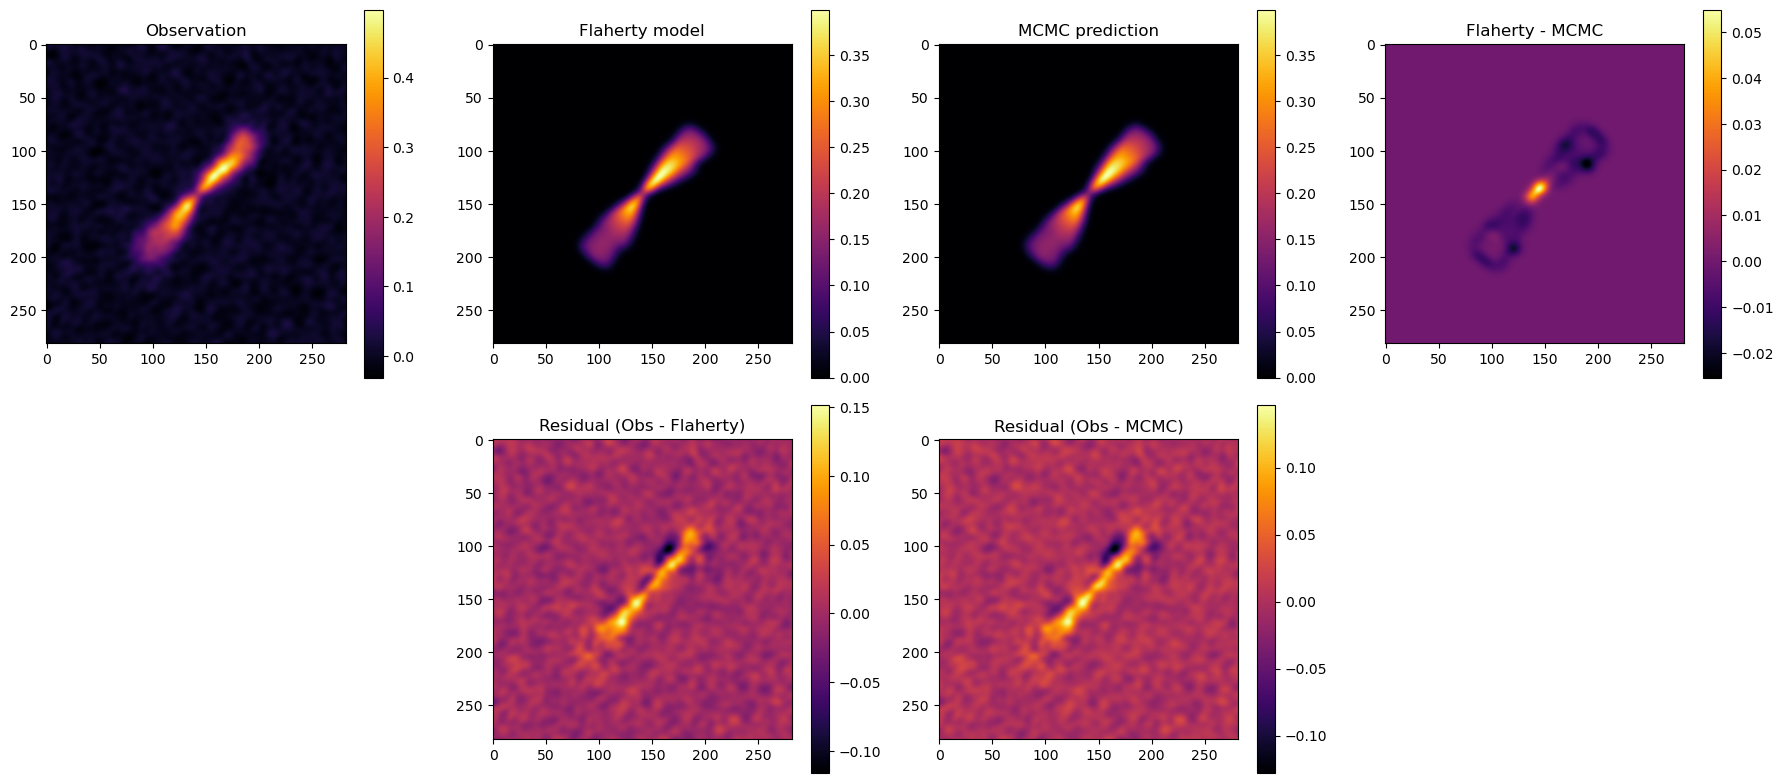

In [41]:
import matplotlib.pyplot as plt

img_index = 15

# Compute residuals
residual_flaherty = data[img_index] - images_blurred[img_index]
residual_mcmc = data[img_index] - images_mcmc_blurred[img_index]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Observation
im0 = axes[0, 0].imshow(data[img_index], cmap='inferno')
axes[0, 0].set_title('Observation')
plt.colorbar(im0, ax=axes[0, 0], orientation='vertical')

# Flaherty model prediction
im1 = axes[0, 1].imshow(images_blurred[img_index], cmap='inferno')
axes[0, 1].set_title('Flaherty model')
plt.colorbar(im1, ax=axes[0, 1], orientation='vertical')

# MCMC prediction
im2 = axes[0, 2].imshow(images_mcmc_blurred[img_index], cmap='inferno')
axes[0, 2].set_title('MCMC prediction')
plt.colorbar(im2, ax=axes[0, 2], orientation='vertical')

# Residual (Observation - Flaherty)
im3 = axes[1, 1].imshow(residual_flaherty, cmap='inferno')
axes[1, 1].set_title('Residual (Obs - Flaherty)')
plt.colorbar(im3, ax=axes[1, 1], orientation='vertical')

# Residual (Observation - MCMC)
im4 = axes[1, 2].imshow(residual_mcmc, cmap='inferno')
axes[1, 2].set_title('Residual (Obs - MCMC)')
plt.colorbar(im4, ax=axes[1, 2], orientation='vertical')

im5 = axes[0, 3].imshow(images_blurred[img_index] - images_mcmc_blurred[img_index], cmap='inferno')
axes[0, 3].set_title('Flaherty - MCMC')
plt.colorbar(im5, ax=axes[0, 3], orientation='vertical')

# Hide the unused bottom-left subplot
axes[1, 0].axis('off')
# Hide the unused bottom-left subplot
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()


In [42]:
residual_flahery = data - images_blurred
chi2_flahery = np.sum(((data - images_blurred) / 0.05)**2)
residual_sum_flahery = np.sum(np.abs(residual_flahery))
residual_mean_flahery = np.mean(np.abs(residual_flahery))

# Number of data points
n_data = np.prod(data.shape)

# Number of fitted parameters (you should set this value based on your model)
k = 8  # Replace 5 with the actual number of fitted parameters in your model
sigma = noise_sigma

# Compute reduced chi-squared
reduced_chi_squared = np.mean(((images_blurred - data)/sigma)**2) / k

print(f"Flahery Chi-squared: {chi2_flahery:.2f}")
print(f"Reduced Chi-squared: {reduced_chi_squared:.5f}")
print(f"Flahery Residual Sum: {residual_sum_flahery:.2f}")
print(f"Flahery Residual Mean: {residual_mean_flahery:.4f}")

Flahery Chi-squared: 252684.31
Reduced Chi-squared: 0.67832
Flahery Residual Sum: 21342.71
Flahery Residual Mean: 0.0089


In [43]:
residual_mcmc = data - images_mcmc_blurred
chi2_mcmc = np.sum(((data - images_mcmc_blurred) / 0.05)**2)
residual_sum_mcmc = np.sum(np.abs(residual_mcmc))
residual_mean_mcmc = np.mean(np.abs(residual_mcmc))

# Number of data points
n_data = data.shape[0] * (data.shape[1] // 5) * (data.shape[1] // 5)

# Number of fitted parameters (you should set this value based on your model)
k = 8  # Replace 5 with the actual number of fitted parameters in your model
sigma=noise_sigma

# Compute reduced chi-squared
reduced_chi_squared_mcmc = np.mean(((images_mcmc_blurred - data)/sigma)**2) / k

print(f"MCMC Chi-squared: {chi2_mcmc:.2f}")
print(f"Reduced Chi-squared: {reduced_chi_squared_mcmc:.5f}")
print(f"MCMC Residual Sum: {residual_sum_mcmc:.2f}")
print(f"MCMC Residual Mean: {residual_mean_mcmc:.4f}")

MCMC Chi-squared: 238042.82
Reduced Chi-squared: 0.63902
MCMC Residual Sum: 20975.51
MCMC Residual Mean: 0.0088


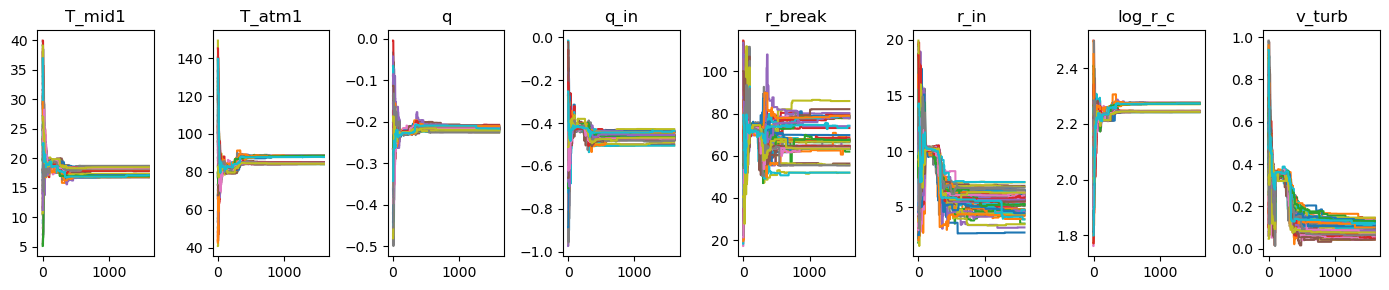

In [34]:
%matplotlib inline
fig, axes = plt.subplots(1, ndim, figsize=(14,3))
for i in range(ndim):
    axes[i].plot(chain[...,i])
    axes[i].set_title(param_labels[i])

plt.tight_layout()

Flat samples shape: (9600, 8)


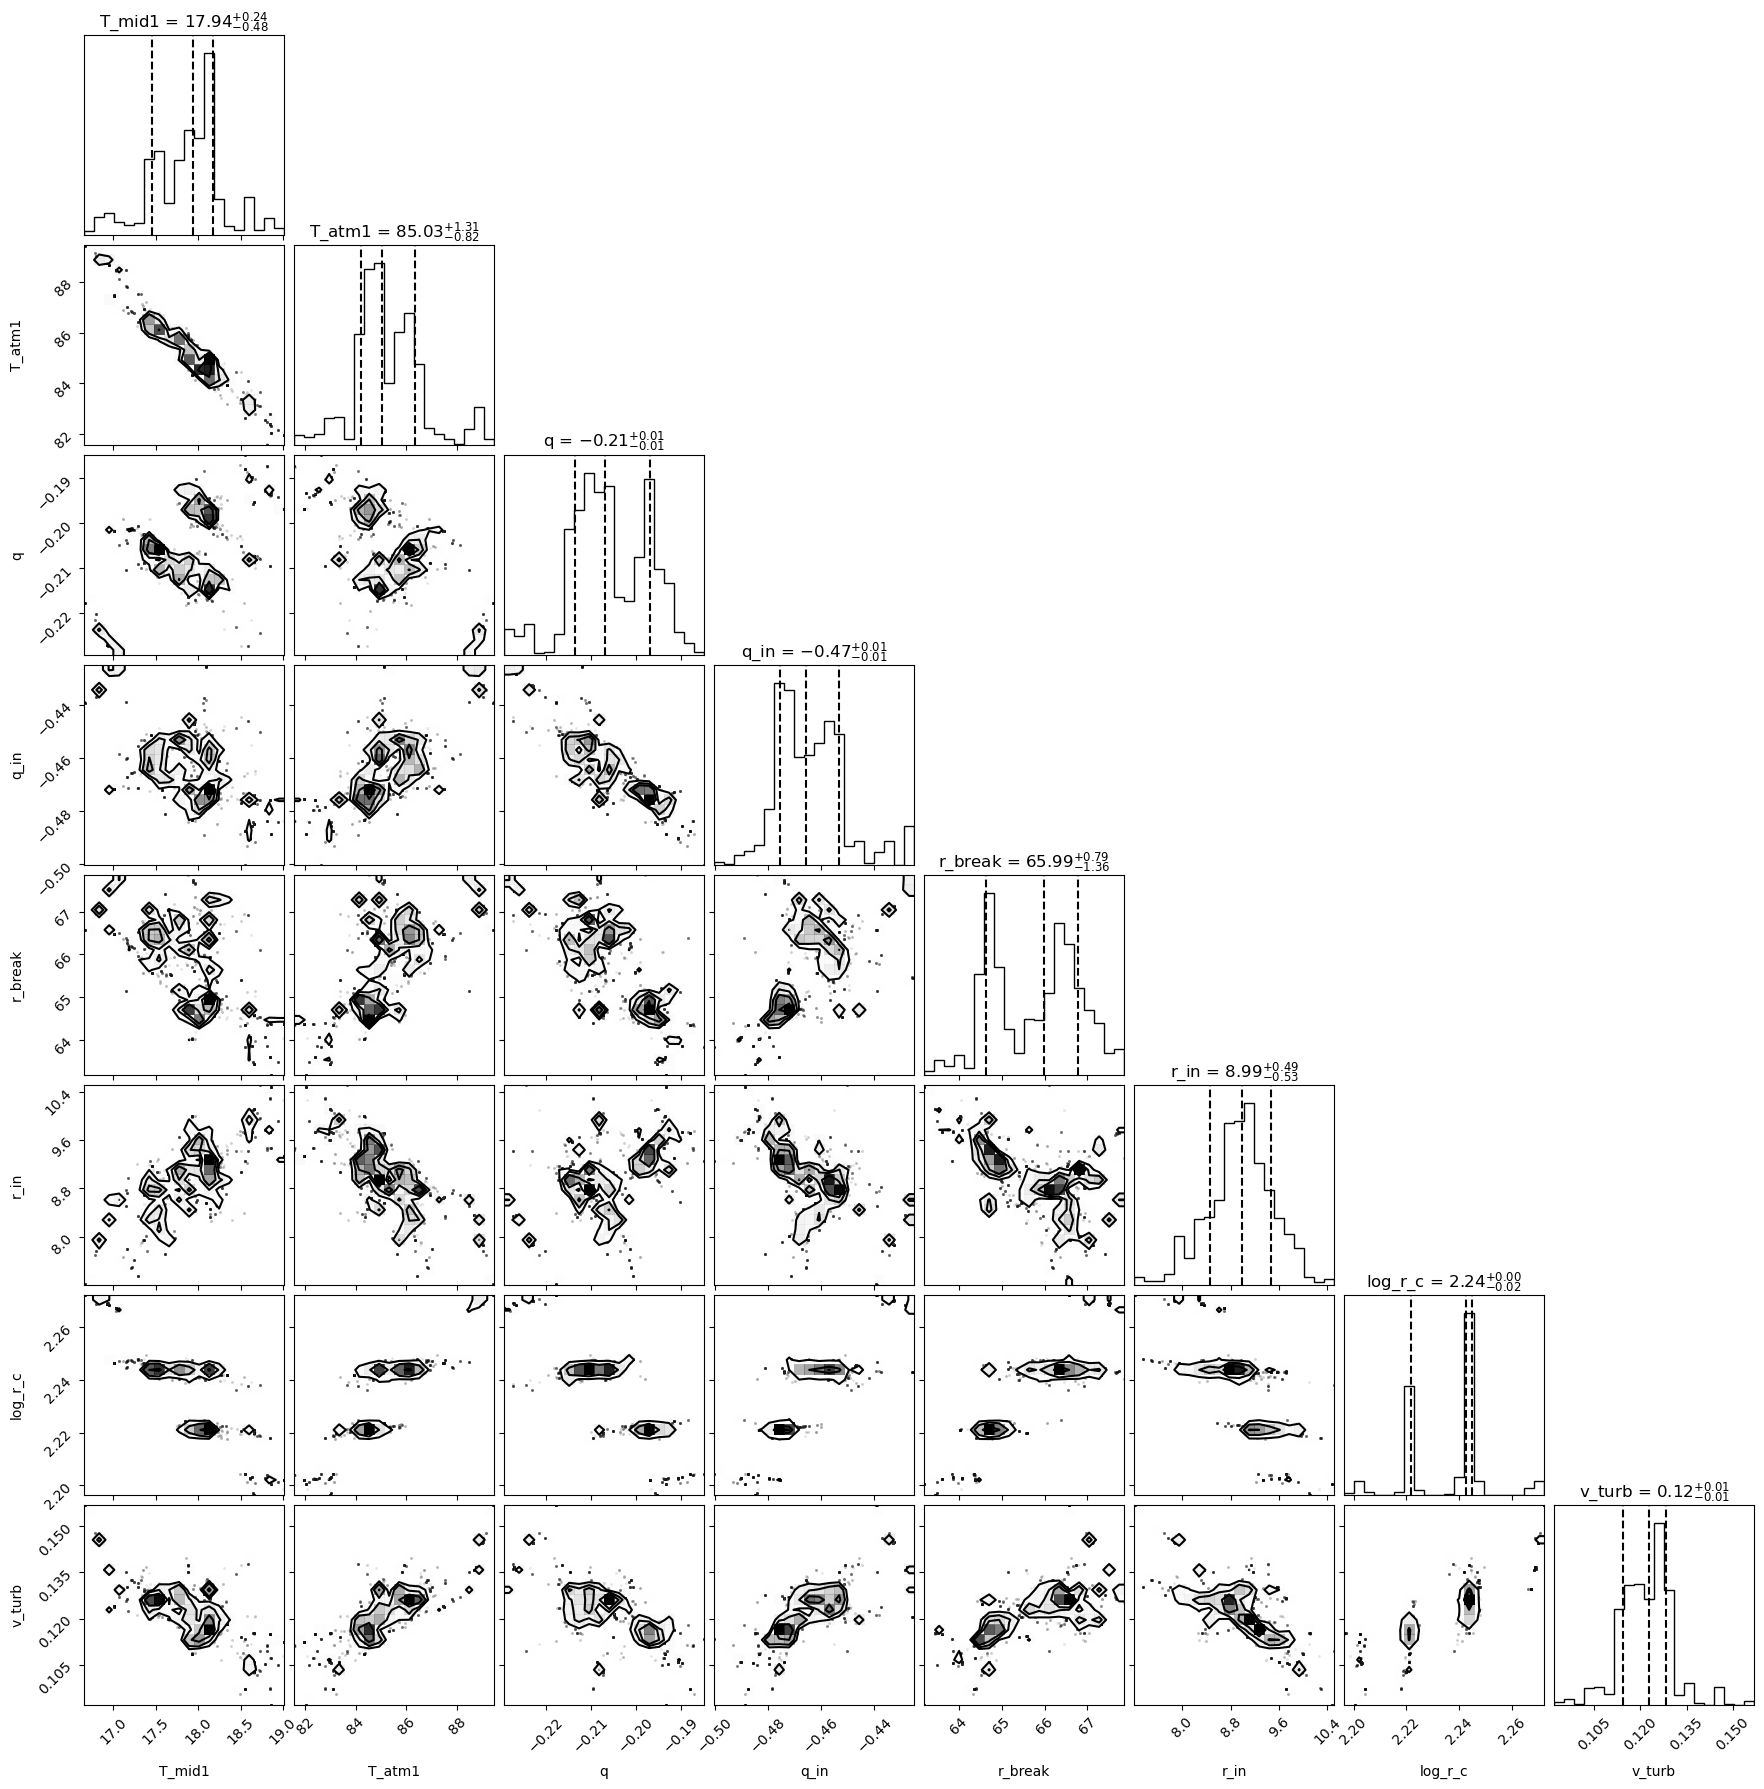

In [66]:
%matplotlib inline
import corner

# Discard first 100 steps, flatten the rest
flat_samples = sampler.get_chain(discard=100, thin=1, flat=True)
print("Flat samples shape:", flat_samples.shape)  # should be ((nsteps-100)*nwalkers, ndim)

param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

# corner plot
fig = corner.corner(
    flat_samples,
    labels=param_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True
)

## Debugging v_turb

Running MCMC...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 60/60 [04:26<00:00,  4.45s/it]


MCMC completed in 271.16 seconds.
computing pinhole spectral cube for a total of 10 frequencies
MCMC Chi-squared: 31040.19, Chi-squared/N_data = 0.03903247538028424
MCMC Residual Sum: 6262.13
MCMC Residual Mean: 0.01


<IPython.core.display.Javascript object>


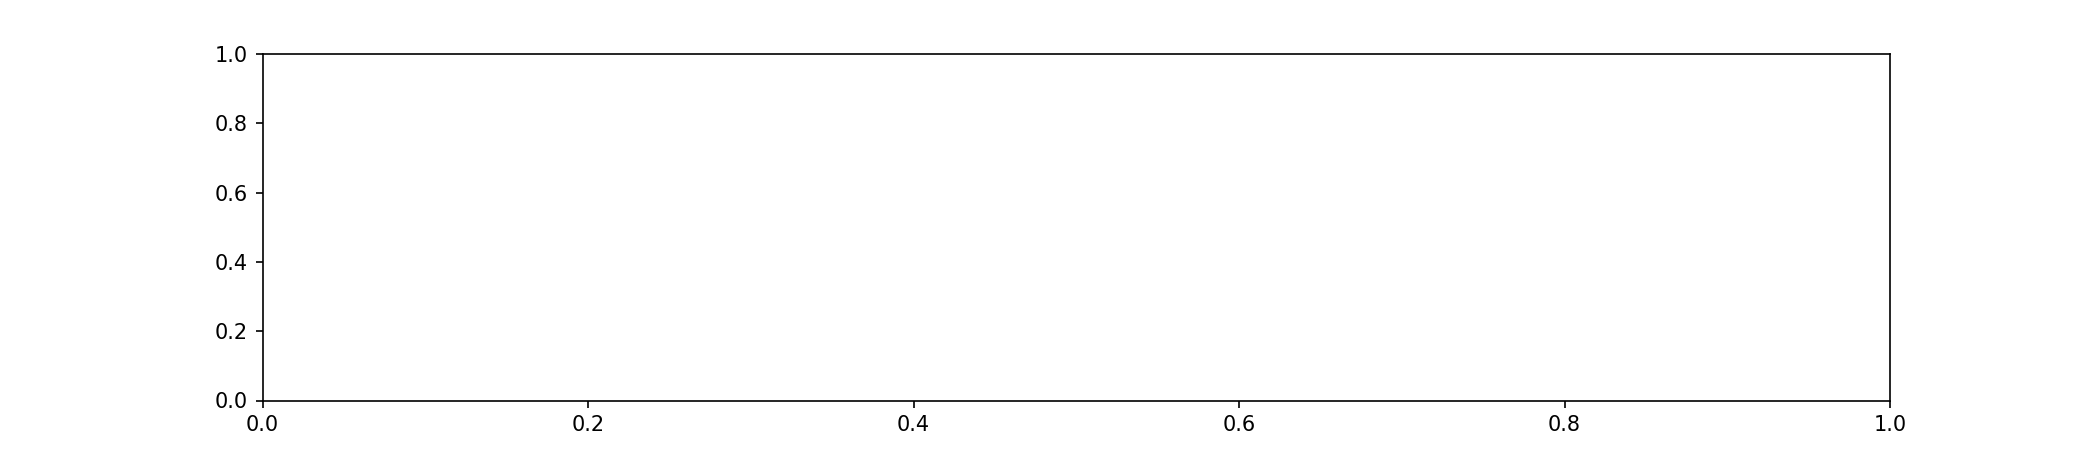

TypeError: 'Axes' object is not subscriptable

In [134]:
import inference 

param_index_dict = inference.DISK_PARAM_INDEX
################################################################################
# 1) Set up the single-parameter prior for v_turb
################################################################################
posterior_params = {
    param_index_dict['v_turb']: {
        'bounds': [0.0, 1.0],
        'p0_range': [0.05, 0.15],
    }
}

# Our disk_params dictionary (already created), e.g.:
disk_params_mcmc = parametric_disk.create_disk_params(
    T_mid1=17.8,
    T_atm1=87.0,
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    M_star=2.3 * M_sun,
    gamma=1.0,
    r_in=11.0,
    log_r_c=2.3,
    M_gas=0.09 * M_sun,
    v_turb=1,  # Just an initial guess; the MCMC will sample this
    co_abundance=1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h
)
    
ray_coords_sph = grid.cartesian_to_spherical(ray_coords_pinhole)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
energy_levels, radiative_transitions = line_rte.load_molecular_tables(
    path="/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"
)

################################################################################
# 2) Create the sampler_dict for the new functional inference
################################################################################
sampler_dict = inference.create_sampler(
    z_disk=z_disk,
    r_disk=r_disk,
    bbox=bbox_disk,
    pixel_area=pixel_area_pinhole,
    ray_coords=ray_coords_pinhole,
    ray_coords_polar=grid.spherical_to_zr(grid.cartesian_to_spherical(ray_coords_pinhole)),
    obs_dir=obs_dir_pinhole,
    beam=beam,
    energy_levels=energy_levels,
    radiative_transitions=radiative_transitions,
    sigma=0.05,
    disk_params=disk_params_mcmc,
    posterior_params=posterior_params,
    stride=None
)

################################################################################
# 3) Initialize the walkers
################################################################################
ndim = len(list(posterior_params.keys()))     # We have only one parameter: v_turb
nwalkers = 32
nsteps = 60 # Example number of MCMC steps

# Sample initial positions p0 from the param_bounds
p0 = inference.sample_p0(nwalkers, posterior_params, seed=1337)

################################################################################
# 4) Set up and run the emcee MCMC
################################################################################
backend = emcee.backends.HDFBackend("mcmc_v_turb_sampler.h5")
backend.reset(nwalkers, ndim)

def logprob_wrapper(params):
    """
    A small wrapper that calls the functional logprob with the 
    arguments we need: the data (images_ground_truth_blurred) 
    and frequencies, plus the sampler_dict.
    """
    return inference.logprob(params, images_noisy_blurred, freqs, sampler_dict)

sampler = emcee.EnsembleSampler(
    nwalkers=nwalkers,
    ndim=ndim,
    log_prob_fn=logprob_wrapper,
    backend=backend
)

print("Running MCMC...")
start_time_mcmc = time.time()
sampler.run_mcmc(p0, nsteps, progress=True)
end_time_mcmc = time.time()
mcmc_time = end_time_mcmc - start_time_mcmc
print(f"MCMC completed in {mcmc_time:.2f} seconds.")

################################################################################
# 6) Update the disk_params with the MCMC result and re-render
################################################################################
samples = sampler.get_chain(flat=True)

# Compute residual metrics for MCMC
v_turb_median = np.median(samples[:, 0])
v_turb_16th, v_turb_84th = np.percentile(samples[:, 0], [16, 84])

# Update the disk with the recovered v_turb
disk_params_mcmc["v_turb"] = v_turb_median

# Recompute temperature and densities with updated v_turb
temperature_mcmc = parametric_disk.temperature_profile(z_disk, r_disk, disk_params_mcmc)
nd_h2_mcmc = parametric_disk.number_density_profile(
    z_disk,
    r_disk,
    temperature_mcmc,
    disk_params_mcmc["gamma"],
    disk_params_mcmc["r_in"],
    10 ** disk_params_mcmc["log_r_c"],
    disk_params_mcmc["M_gas"],
    disk_params_mcmc["M_star"],
    disk_params_mcmc["m_mol"]
)

velocity_az_mcmc = -parametric_disk.velocity_profile(
    z_disk, r_disk, nd_h2_mcmc, temperature_mcmc, disk_params_mcmc
)

N_h2_mcmc = parametric_disk.surface_density(z_disk, nd_h2_mcmc)
abundance_co_mcmc = parametric_disk.co_abundance_profile(N_h2_mcmc, temperature_mcmc, disk_params_mcmc)
nd_co_mcmc = abundance_co_mcmc * nd_h2_mcmc

# Render new cube with the updated v_turb
images_mcmc = render_cube_pinhole(
    ray_coords=ray_coords_pinhole,
    pixel_area=pixel_area_pinhole,
    disk_params=disk_params_mcmc,       # pass the dictionary instead of a disk object
    nd_co=nd_co_mcmc,
    temperature=temperature_mcmc,
    velocity_az=velocity_az_mcmc,
    bbox=bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)

images_mcmc_blurred = sensor.fftconvolve_vmap(images_mcmc, beam)

residual_mcmc = images_noisy_blurred - images_mcmc_blurred
chi2_mcmc = np.sum(((images_noisy_blurred - images_mcmc_blurred) / 0.05)**2)
residual_sum_mcmc = np.sum(np.abs(residual_mcmc))
residual_mean_mcmc = np.mean(np.abs(residual_mcmc))

n_data = np.prod(data.shape)
chi_squared_over_n_data = chi2_mcmc / n_data

print(f"MCMC Chi-squared: {chi2_mcmc:.2f}, Chi-squared/N_data = {chi_squared_over_n_data}")
print(f"MCMC Residual Sum: {residual_sum_mcmc:.2f}")
print(f"MCMC Residual Mean: {residual_mean_mcmc:.2f}")

chain = sampler.get_chain()

ndim = chain.shape[-1]
param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

%matplotlib notebook
fig, axes = plt.subplots(1, ndim, figsize=(14,3))
for i in range(ndim):
    axes[i].plot(chain[...,i])
    axes[i].set_title(param_labels[i])

plt.tight_layout()

<IPython.core.display.Javascript object>


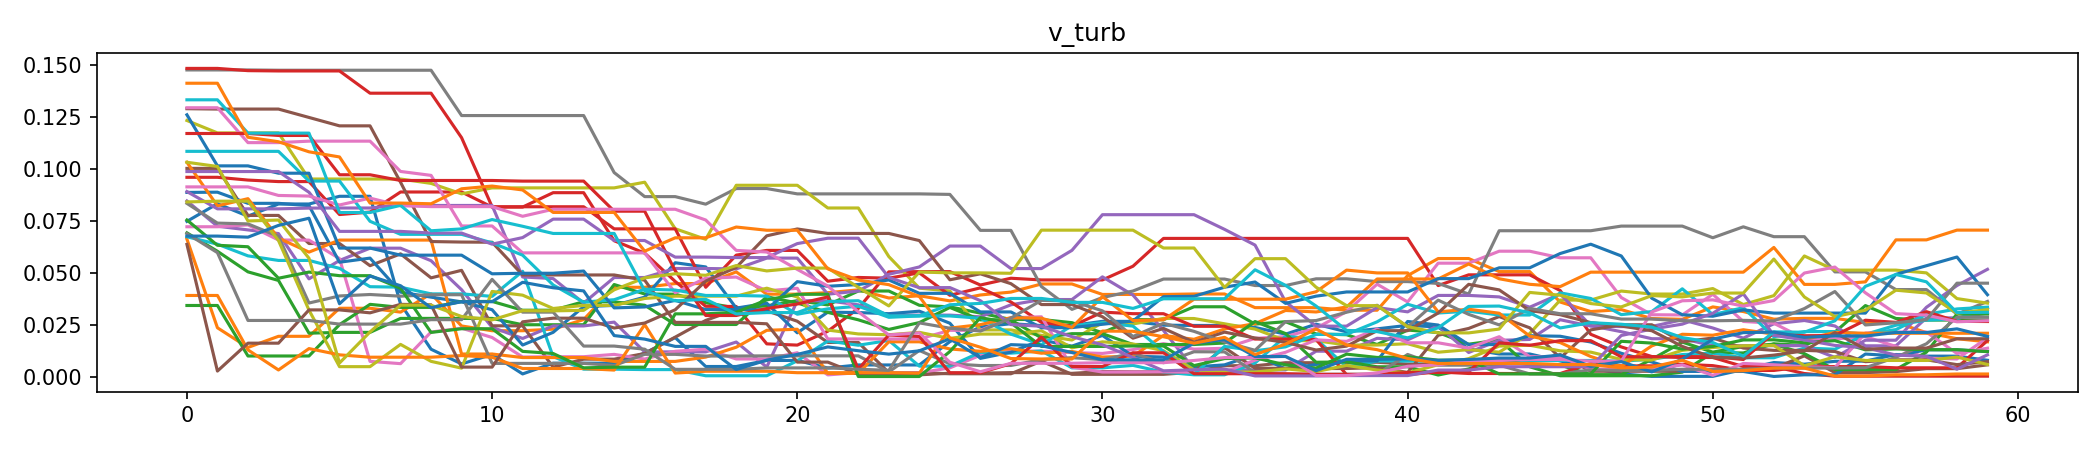

In [135]:
fig, axes = plt.subplots(1, ndim, figsize=(14,3))
axes.plot(chain[...,0])
axes.set_title(param_labels[0])

plt.tight_layout()

In [136]:
flat_samples = sampler.get_chain(discard=20, thin=1, flat=True)
param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]
p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
print(f"{param_labels[0]:8s} | MCMC: {p50:.3f} (+{p84 - p50:.3f} / -{p50 - p16:.3f})")

v_turb   | MCMC: 0.020 (+0.021 / -0.015)


In [141]:
disk_params_mcmc['v_turb']

np.float64(0.02639049117208694)

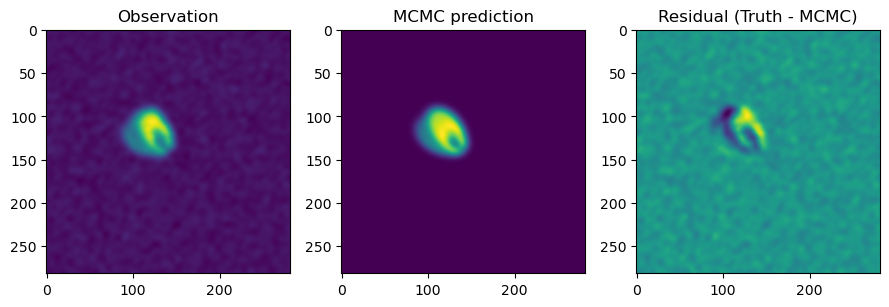

In [169]:
%matplotlib inline
img_index = 3
fig, axes = plt.subplots(1, 3, figsize=(9,3))
axes[0].imshow(data[img_index])
axes[0].set_title('Observation')
axes[1].imshow(images_mcmc_blurred[img_index])
axes[1].set_title('MCMC prediction')
axes[2].imshow(residual_mcmc[img_index])
axes[2].set_title('Residual (Truth - MCMC)')
plt.tight_layout()

In [38]:
disk_params_true = disk_params_mcmc.copy()

# ground_truth = {
#     "q": -0.27,
#     "log_r_c": 2.3,
#     "v_turb": 0.06,
#     "T_atm1": 87.0,
#     "T_mid1": 17.8,
#     "r_in": 11.0,
#     "r_break": 70.0,
#     "q_in": -0.57
# }

disk_params_true["v_turb"] = 0.06
disk_params_true["v_turb"] = 0.06
disk_params_true["v_turb"] = 0.06

# Recompute temperature and densities with updated v_turb
temperature_true = parametric_disk.temperature_profile(z_disk, r_disk, disk_params_true)
nd_h2_true = parametric_disk.number_density_profile(
    z_disk,
    r_disk,
    temperature_true,
    disk_params_true["gamma"],
    disk_params_true["r_in"],
    10 ** disk_params_true["log_r_c"],
    disk_params_true["M_gas"],
    disk_params_true["M_star"],
    disk_params_true["m_mol"]
)

velocity_az_true = -parametric_disk.velocity_profile(
    z_disk, r_disk, nd_h2_true, temperature_true, disk_params_true
)

N_h2_true = parametric_disk.surface_density(z_disk, nd_h2_true)
abundance_co_true = parametric_disk.co_abundance_profile(N_h2_true, temperature_true, disk_params_true)
nd_co_true = abundance_co_true * nd_h2_true

# Render new cube with the updated v_turb
images_true = render_cube_pinhole(
    ray_coords=ray_coords_pinhole,
    pixel_area=pixel_area_pinhole,
    disk_params=disk_params_true,       # pass the dictionary instead of a disk object
    nd_co=nd_co_true,
    temperature=temperature_true,
    velocity_az=velocity_az_true,
    bbox=bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)

images_true_blurred = sensor.fftconvolve_vmap(images_true, beam)

residual_true = images_noisy_blurred - images_true_blurred
chi2_true = np.sum(((images_noisy_blurred - images_true_blurred) / 0.05)**2)
residual_sum_true = np.sum(np.abs(residual_true))
residual_mean_true = np.mean(np.abs(residual_true))

n_data = np.prod(data.shape)
chi_squared_over_n_data = chi2_true / n_data

print(f"MCMC Chi-squared: {chi2_true:.2f}, Chi-squared/N_data = {chi_squared_over_n_data}")
print(f"MCMC Residual Sum: {residual_sum_true:.2f}")
print(f"MCMC Residual Mean: {residual_mean_true:.2f}")


computing pinhole spectral cube for a total of 80 frequencies
MCMC Chi-squared: 252336.99, Chi-squared/N_data = 0.039663653612947505
MCMC Residual Sum: 50578.72
MCMC Residual Mean: 0.01


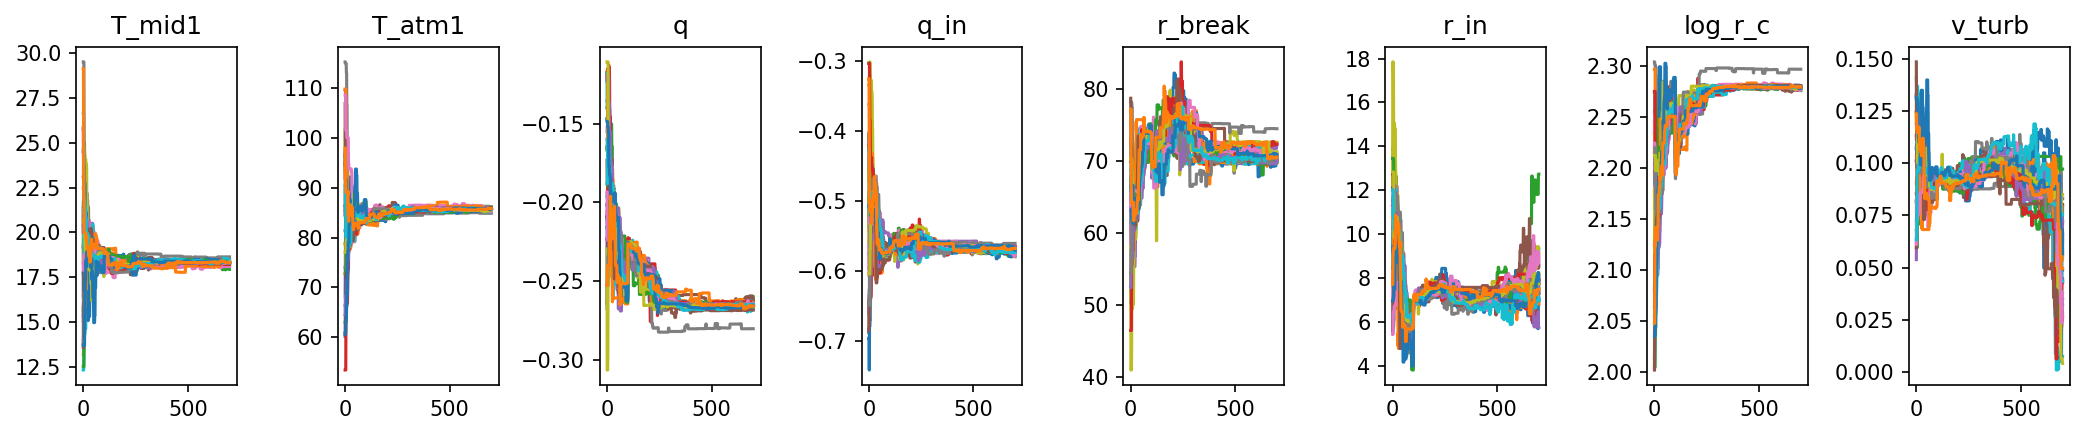

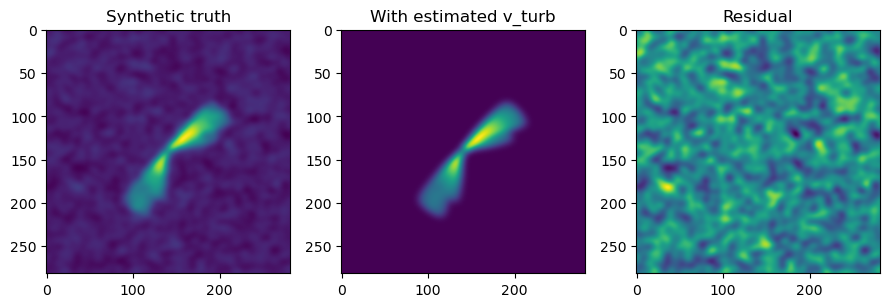

In [255]:
%matplotlib inline
img_index = 5
fig, axes = plt.subplots(1, 3, figsize=(9,3))
axes[0].imshow(images_noisy_blurred[img_index])
axes[0].set_title('Synthetic truth')
axes[1].imshow(images_mcmc_blurred[img_index])
axes[1].set_title('With estimated v_turb')
axes[2].imshow(residual_mcmc[img_index])
axes[2].set_title('Residual')
plt.tight_layout()

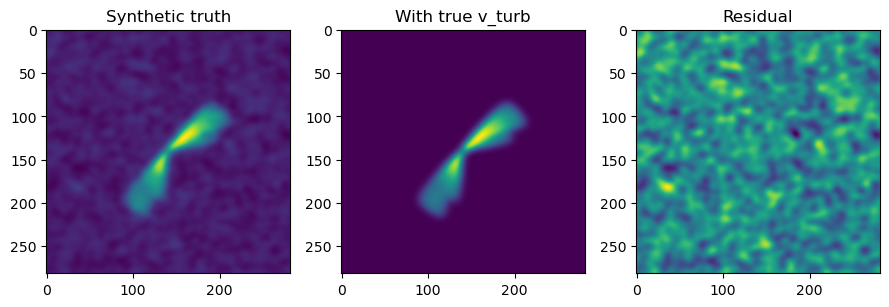

In [256]:
%matplotlib inline
img_index = 5
fig, axes = plt.subplots(1, 3, figsize=(9,3))
axes[0].imshow(images_noisy_blurred[img_index])
axes[0].set_title('Synthetic truth')
axes[1].imshow(images_true_blurred[img_index])
axes[1].set_title('With true v_turb')
axes[2].imshow(residual_true[img_index])
axes[2].set_title('Residual')
plt.tight_layout()

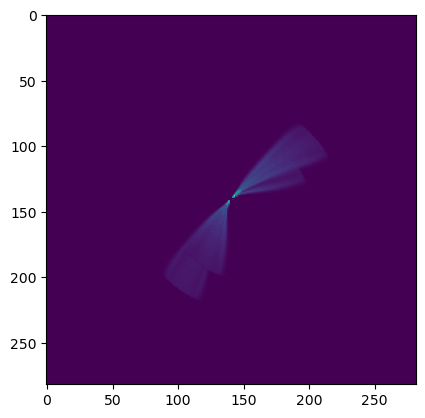

In [224]:
plt.imshow(images[img_index])

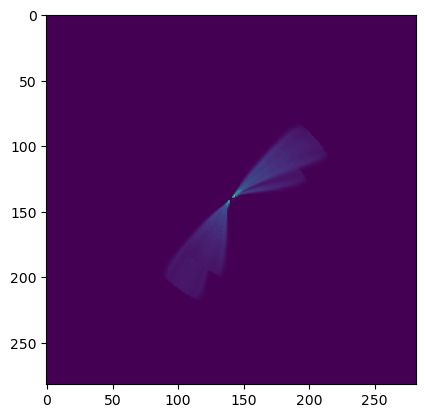

In [225]:
plt.imshow(images_mcmc[img_index])

In [228]:
np.sum(np.abs(images - images_true))

np.float64(36163.49796890723)

In [229]:
np.sum(np.abs(images - images_mcmc))

np.float64(36800.89594647572)

In [230]:
np.sum(np.abs(images - images_mcmc))

np.float64(36800.89594647572)